**bold text**# FairCVdb — Model Training & Fairness Evaluation
**Models:** Logistic Regression · Random Forest · Multi-Layer Perceptron  
**Paper:** Peña et al., *Human-Centric Multimodal Machine Learning*, Springer 2023  

---
### Experimental Design
| Setting | Features Used | Purpose |
|---|---|---|
| A | Competency only | Merit-based baseline |
| B | Competency + Demographics | Proxy bias measurement |
| C | Competency + Face Embedding | Face-aware model |
| D | Competency + Blind Face Emb | De-biased face model |

| Label | Meaning |
|---|---|
| `blind_label` | Fair score — no demographic penalty |
| `biased_label_gender` | Female penalized ~25% |
| `biased_label_ethnicity` | G1 & G3 penalized |

---
## 0. Setup & Install

In [ ]:
import io, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, confusion_matrix,
                                      classification_report, roc_curve, auc)
from sklearn.inspection       import permutation_importance
from scipy                    import stats
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})
sns.set_theme(style='whitegrid', font_scale=1.0)

# ── Color palettes ──────────────────────────────────────────────────
PAL_MODEL   = {'LR': '#3498DB', 'RF': '#27AE60', 'MLP': '#E67E22'}
PAL_GENDER  = {0: '#3A7FD5', 1: '#E8567A'}
PAL_ETH     = {0: '#F5A623', 1: '#7B68EE', 2: '#50C878'}
PAL_SETTING = {'A':'#1ABC9C','B':'#E74C3C','C':'#9B59B6','D':'#F39C12'}
PAL_LABEL   = {'blind':'#27AE60','gender':'#E74C3C','ethnicity':'#E67E22'}

# ── Column definitions ──────────────────────────────────────────────
COMPETENCY  = ['suitability','educ_attainment','prev_experience',
               'recommendation','availability','lang_prof_1','lang_prof_2','lang_prof_3']
COMP_NAMES  = ['Suitability','Education','Experience','Recommendation',
               'Availability','Language 1','Language 2','Language 3']
DEMO_COLS   = ['gender','ethnicity']
FACE_COLS   = [f'face_emb_{i}'       for i in range(20)]
BLIND_COLS  = [f'blind_face_emb_{i}' for i in range(20)]
LABEL_COLS  = ['blind_label','biased_label_gender','biased_label_ethnicity']
LABEL_SHORT = ['blind','gender','ethnicity']

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Setup complete')

Setup complete


---
## 1. Data Loading & Preprocessing

In [ ]:
from google.colab import files
print('Upload FairCVdb.csv...')
uploaded = files.upload()
fname = [k for k in uploaded if k.endswith('.csv')][0]
df    = pd.read_csv(io.BytesIO(uploaded[fname]))

# Reconstruct train/test split (paper: 19200 train / 4800 test)
df['split'] = ['train'] * 19200 + ['test'] * 4800
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Upload FairCVdb.csv...


Saving FairCVdb.csv to FairCVdb.csv
Loaded: 24,000 rows × 60 columns


In [ ]:
# ════════════════════════════════════════════════════════════════════
# PREPROCESSING
#
# Decision: convert continuous labels → binary classification
# Threshold = median of blind_label (ensures 50/50 class balance).
# Class 1 = 'Recommended' (score ≥ threshold)
# Class 0 = 'Not Recommended' (score < threshold)
#
# Why median? Avoids threshold bias and gives balanced classes,
# which is required for fair F1/AUC evaluation.
# ════════════════════════════════════════════════════════════════════

THRESHOLD = df['blind_label'].median()  # 0.413 — derived from blind (fair) label
print(f'Binarization threshold (blind_label median): {THRESHOLD:.4f}')

for label_col, short in zip(LABEL_COLS, LABEL_SHORT):
    df[f'y_{short}'] = (df[label_col] >= THRESHOLD).astype(int)
    pos_rate = df[f'y_{short}'].mean()
    print(f'  y_{short:10s}: class 1 = {pos_rate*100:.1f}%  class 0 = {(1-pos_rate)*100:.1f}%')

print('\nMissing values:', df[COMPETENCY + DEMO_COLS + FACE_COLS + BLIND_COLS].isnull().sum().sum())

# ── Feature sets (4 settings per paper) ────────────────────────────
# NOTE: blind_face_emb has near-zero variance (SensitiveNets compressed
# demographic info into a constant-like representation). We include it
# for academic comparison but expect minimal contribution to accuracy.

FEATURE_SETS = {
    'A: Competency Only':           COMPETENCY,
    'B: Competency + Demographics': COMPETENCY + DEMO_COLS,
    'C: Competency + Face Emb':     COMPETENCY + FACE_COLS,
    'D: Competency + Blind Emb':    COMPETENCY + BLIND_COLS,
}

print('\nFeature set sizes:')
for name, cols in FEATURE_SETS.items():
    print(f'  {name}: {len(cols)} features')

Binarization threshold (blind_label median): 0.4130
  y_blind     : class 1 = 50.0%  class 0 = 50.0%
  y_gender    : class 1 = 36.7%  class 0 = 63.3%
  y_ethnicity : class 1 = 50.2%  class 0 = 49.8%

Missing values: 0

Feature set sizes:
  A: Competency Only: 8 features
  B: Competency + Demographics: 10 features
  C: Competency + Face Emb: 28 features
  D: Competency + Blind Emb: 28 features


In [ ]:
# ── Helper: build X_train, X_test, y_train, y_test ─────────────────
def get_split(feature_cols, label_col, scale=True):
    """
    Returns scaled train/test arrays for a given feature set and label.
    Uses the paper's predefined train/test split (rows 0-19199 = train).
    Scaling: StandardScaler fit ONLY on train to avoid data leakage.
    """
    train = df[df['split'] == 'train'].reset_index(drop=True)
    test  = df[df['split'] == 'test'].reset_index(drop=True)

    X_tr = train[feature_cols].values.astype(float)
    X_te = test[feature_cols].values.astype(float)
    y_tr = train[label_col].values
    y_te = test[label_col].values

    if scale:
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)   # fit on train only
        X_te   = scaler.transform(X_te)        # apply same transform to test

    return X_tr, X_te, y_tr, y_te

# ── Demographic arrays for fairness analysis ─────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

gender_tr    = train_df['gender'].values
gender_te    = test_df['gender'].values
ethnicity_tr = train_df['ethnicity'].values
ethnicity_te = test_df['ethnicity'].values

print(' Preprocessing complete. Data split:')
print(f'  Train: {len(train_df):,} | Test: {len(test_df):,}')

 Preprocessing complete. Data split:
  Train: 19,200 | Test: 4,800


---
## 2. Evaluation & Fairness Functions

In [ ]:
# ════════════════════════════════════════════════════════════════════
# Centralized evaluation functions — used by all models.
# Keeps code DRY and ensures consistent metric computation.
# ════════════════════════════════════════════════════════════════════

def compute_metrics(y_true, y_pred, y_prob=None):
    """Returns dict of standard classification metrics."""
    m = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        m['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return m

def compute_group_metrics(y_true, y_pred, group_arr, group_labels):
    """
    Computes per-group accuracy and positive prediction rate.
    Positive prediction rate = P(ŷ=1 | group=g) — Demographic Parity.
    """
    rows = []
    for gid, gname in group_labels.items():
        mask  = (group_arr == gid)
        yt    = y_true[mask]; yp = y_pred[mask]
        rows.append({
            'Group':     gname,
            'N':         mask.sum(),
            'Accuracy':  accuracy_score(yt, yp),
            'F1':        f1_score(yt, yp, zero_division=0),
            'Pos Rate':  yp.mean(),          # demographic parity metric
            'True Pos Rate': (yt[yp==1]==1).sum() / (yt==1).sum() if (yt==1).sum()>0 else 0,
        })
    result_df = pd.DataFrame(rows).set_index('Group')
    result_df['DP Gap']  = result_df['Pos Rate'].max()  - result_df['Pos Rate'].min()
    result_df['EOO Gap'] = result_df['True Pos Rate'].max() - result_df['True Pos Rate'].min()
    return result_df

def plot_confusion_matrix(y_true, y_pred, title, ax, cmap='Blues'):
    """Annotated confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Rec.','Rec.'],
                yticklabels=['Not Rec.','Rec.'],
                linewidths=0.5, cbar=False,
                annot_kws={'size': 11})
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    # Add TN/FP/FN/TP labels
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.05, -0.12, f'TN={tn} FP={fp} FN={fn} TP={tp}',
            transform=ax.transAxes, fontsize=8, color='gray')

def plot_roc(y_true, y_prob, label, ax, color):
    """Single ROC curve on a given axis."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={auc_val:.3f})')
    return auc_val

def fairness_summary_plot(fairness_dict, title, save_name):
    """
    Plots Demographic Parity Gap and EOO Gap across
    models, settings, and label types.
    """
    rows = []
    for key, df_f in fairness_dict.items():
        rows.append({'Key': key,
                     'DP Gap':  df_f['DP Gap'].mean(),
                     'EOO Gap': df_f['EOO Gap'].mean()})
    plot_df = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, metric in zip(axes, ['DP Gap','EOO Gap']):
        bars = ax.bar(plot_df['Key'], plot_df[metric],
                      color='#3498DB', edgecolor='white', width=0.6, alpha=0.85)
        ax.set_title(metric, fontweight='bold')
        ax.set_ylabel(metric + ' (lower = fairer)')
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        for bar, val in zip(bars, plot_df[metric]):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.003, f'{val:.4f}',
                    ha='center', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', dpi=150)
    plt.show()

GENDER_LABELS = {0: 'Male', 1: 'Female'}
ETH_LABELS    = {0: 'G1',   1: 'G2',   2: 'G3'}

print(' Evaluation functions defined')

 Evaluation functions defined


---
## 3. Baseline Models (Structured Only)

### 3.1 Logistic Regression

In [ ]:
# ════════════════════════════════════════════════════════════════════
# LOGISTIC REGRESSION
#
# Why: Linear baseline. Coefficients are interpretable — directly shows
#      which features push a candidate toward 'Recommended'.
# Scaling: Required for LR (gradient convergence).
# Regularization: L2 (default) prevents overfitting on 8-28 features.
# Hyperparameter search: tune C (regularization strength).
# ════════════════════════════════════════════════════════════════════

print('=== LOGISTIC REGRESSION ===')
print('Hyperparameter search: C over [0.001, 0.01, 0.1, 1, 10, 100]...')

# ── GridSearch on Setting A, blind_label ────────────────────────────
from sklearn.model_selection import GridSearchCV

X_tr_A, X_te_A, y_tr_blind, y_te_blind = get_split(COMPETENCY, 'y_blind')

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, solver='lbfgs'),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1', n_jobs=-1, verbose=0
)
lr_grid.fit(X_tr_A, y_tr_blind)
best_C = lr_grid.best_params_['C']
print(f'Best C = {best_C} (F1 = {lr_grid.best_score_:.4f})')

# ── Display GridSearch Results ──────────────────────────────────────
cv_results = pd.DataFrame(lr_grid.cv_results_)
print("\n📊 Hyperparameter Tuning Results:")
print("─" * 70)
print(f"{'C':<15} {'Mean F1':<15} {'Std F1':<15} {'Best':<10}")
print("─" * 70)
for idx, row in cv_results.iterrows():
    c_val = row['param_C']
    mean_f1 = row['mean_test_score']
    std_f1 = row['std_test_score']
    is_best = "✓ BEST" if c_val == best_C else ""
    print(f"{c_val:<15.4f} {mean_f1:<15.4f} {std_f1:<15.4f} {is_best:<10}")
print("─" * 70)

=== LOGISTIC REGRESSION ===
Hyperparameter search: C over [0.001, 0.01, 0.1, 1, 10, 100]...
Best C = 100 (F1 = 0.9714)

📊 Hyperparameter Tuning Results:
──────────────────────────────────────────────────────────────────────
C               Mean F1         Std F1          Best      
──────────────────────────────────────────────────────────────────────
0.0010          0.9628          0.0034                    
0.0100          0.9704          0.0019                    
0.1000          0.9714          0.0016                    
1.0000          0.9714          0.0019                    
10.0000         0.9714          0.0020                    
100.0000        0.9714          0.0021          ✓ BEST    
──────────────────────────────────────────────────────────────────────


In [ ]:
# ── Train LR across all settings × all labels ───────────────────────
lr_results    = {}   # perf metrics
lr_fairness_g = {}   # gender fairness
lr_fairness_e = {}   # ethnicity fairness
lr_models     = {}   # store trained models

for setting_name, feat_cols in FEATURE_SETS.items():
    for label_col, short in zip(['y_blind','y_gender','y_ethnicity'], LABEL_SHORT):
        key = f'{setting_name} | {short}'
        X_tr, X_te, y_tr, y_te = get_split(feat_cols, label_col)

        lr = LogisticRegression(C=best_C, max_iter=1000,
                                random_state=RANDOM_SEED, solver='lbfgs')
        lr.fit(X_tr, y_tr)
        y_pred = lr.predict(X_te)
        y_prob = lr.predict_proba(X_te)[:, 1]

        lr_results[key]    = compute_metrics(y_te, y_pred, y_prob)
        lr_fairness_g[key] = compute_group_metrics(y_te, y_pred, gender_te,    GENDER_LABELS)
        lr_fairness_e[key] = compute_group_metrics(y_te, y_pred, ethnicity_te, ETH_LABELS)
        lr_models[key]     = (lr, feat_cols, y_te, y_pred, y_prob)

lr_perf_df = pd.DataFrame(lr_results).T.round(4)
print('\n Logistic Regression — Full Performance Table:')
display(lr_perf_df)


 Logistic Regression — Full Performance Table:


,Accuracy,Precision,Recall,F1,ROC-AUC
A: Competency Only | blind,0.9665,0.9734,0.9583,0.9658,0.9966
A: Competency Only | gender,0.8638,0.8381,0.7768,0.8063,0.9572
A: Competency Only | ethnicity,0.8233,0.8176,0.8259,0.8217,0.9182
B: Competency + Demographics | blind,0.9665,0.9734,0.9583,0.9658,0.9966
B: Competency + Demographics | gender,0.9646,0.9583,0.9441,0.9511,0.9956
B: Competency + Demographics | ethnicity,0.9698,0.9776,0.9607,0.9691,0.9969
C: Competency + Face Emb | blind,0.9648,0.9685,0.9599,0.9642,0.9965
C: Competency + Face Emb | gender,0.9194,0.9017,0.8744,0.8879,0.9789
C: Competency + Face Emb | ethnicity,0.8604,0.8587,0.8580,0.8584,0.9431
D: Competency + Blind Emb | blind,0.9656,0.9710,0.9591,0.9650,0.9965



              precision    recall  f1-score   support

    Not Rec.       0.96      0.97      0.97      2428
        Rec.       0.97      0.96      0.97      2372

    accuracy                           0.97      4800
   macro avg       0.97      0.97      0.97      4800
weighted avg       0.97      0.97      0.97      4800



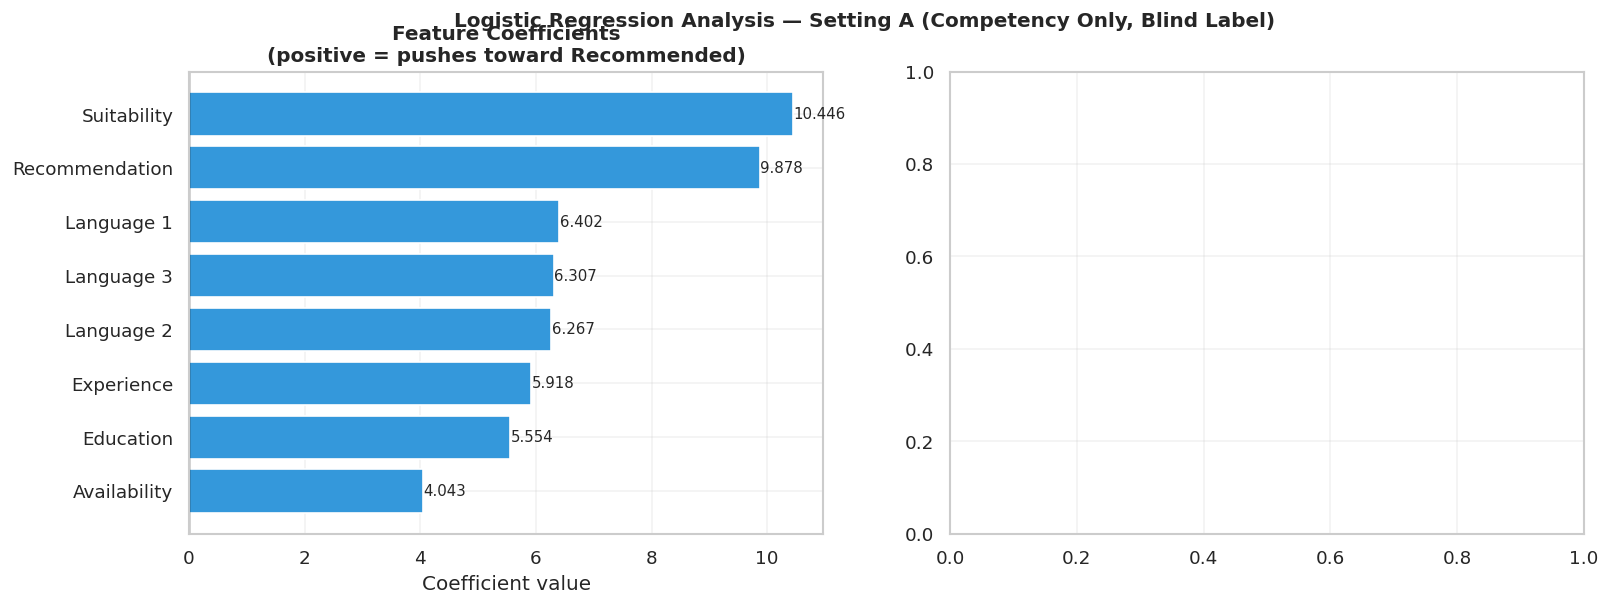

In [ ]:
# ── LR: Coefficient analysis (Setting A, blind_label) ───────────────
# Coefficients = direct weight each feature has on prediction.
# Positive = increases P(Recommended); Negative = decreases it.

key_A = 'A: Competency Only | blind'
lr_A, feat_A, y_te_A, y_pred_A, y_prob_A = lr_models[key_A]

coef_df = pd.DataFrame({
    'Feature':     COMP_NAMES,
    'Coefficient': lr_A.coef_[0]
}).sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Logistic Regression Analysis — Setting A (Competency Only, Blind Label)',
             fontsize=12, fontweight='bold')

# Coefficient bar chart
colors = [PAL_MODEL['LR'] if v >= 0 else '#E74C3C' for v in coef_df['Coefficient']]
bars   = axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
                      color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Feature Coefficients\n(positive = pushes toward Recommended)',
                  fontweight='bold')
axes[0].set_xlabel('Coefficient value')
for bar, val in zip(bars, coef_df['Coefficient']):
    x = val + 0.005 if val >= 0 else val - 0.005
    axes[0].text(x, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)


print(f'\n{classification_report(y_te_A, y_pred_A, target_names=["Not Rec.","Rec."])}')

In [ ]:
# ── LR: Fairness analysis ────────────────────────────────────────────
print(' LR Fairness — Gender (Setting A, blind label):')
display(lr_fairness_g['A: Competency Only | blind'].round(4))

print('\n LR Fairness — Ethnicity (Setting A, blind label):')
display(lr_fairness_e['A: Competency Only | blind'].round(4))

# Compare gender fairness across labels
print('\n LR Gender DP Gap: blind vs biased labels (Setting A):')
for short in LABEL_SHORT:
    key = f'A: Competency Only | {short}'
    dp  = lr_fairness_g[key]['DP Gap'].mean()
    eoo = lr_fairness_g[key]['EOO Gap'].mean()
    print(f'  {short:12s}: DP Gap={dp:.4f}  EOO Gap={eoo:.4f}')

 LR Fairness — Gender (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
Male,2437,0.9659,0.9654,0.4887,0.9579,0.0046,0.0008
Female,2363,0.9670,0.9662,0.4841,0.9587,0.0046,0.0008



 LR Fairness — Ethnicity (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
G1,1595,0.9687,0.9690,0.5016,0.9618,0.023,0.0075
G2,1588,0.9666,0.9654,0.4786,0.9585,0.023,0.0075
G3,1617,0.9641,0.9629,0.4793,0.9544,0.023,0.0075



 LR Gender DP Gap: blind vs biased labels (Setting A):
  blind       : DP Gap=0.0046  EOO Gap=0.0008
  gender      : DP Gap=0.0038  EOO Gap=0.3205
  ethnicity   : DP Gap=0.0029  EOO Gap=0.0110


In [ ]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_tr_s, X_te_s, y_tr_s, y_te_s = get_split(COMPETENCY, 'y_blind', scale=True)
scaler_app = StandardScaler().fit(
    df[df['split']=='train'][COMPETENCY].values.astype(float))
model_app = LogisticRegression(C=best_C, max_iter=1000,
                               random_state=RANDOM_SEED, solver='lbfgs')
model_app.fit(X_tr_s, y_tr_s)
joblib.dump(model_app,  'model_structured.pkl')
joblib.dump(scaler_app, 'scaler_structured.pkl')
print("✓ Đã lưu 2 file pkl")

✓ Đã lưu 2 file pkl



### 3.2 Random Forest

In [ ]:
# ════════════════════════════════════════════════════════════════════
# RANDOM FOREST
#
# Why: Ensemble of decision trees. Captures non-linear interactions
#      between competency features. Feature importance via mean
#      impurity decrease (Gini importance).
# No scaling needed: tree-based model is scale-invariant.
# Hyperparameter search: n_estimators, max_depth, min_samples_leaf.
# ════════════════════════════════════════════════════════════════════

print('=== RANDOM FOREST ===')
print('RandomizedSearchCV: 20 combinations × 3-fold CV...')

X_tr_A_raw, X_te_A_raw, y_tr_blind, y_te_blind = get_split(
    COMPETENCY, 'y_blind', scale=False)  # RF does not need scaling

rf_param_dist = {
    'n_estimators':     [50, 100, 200, 300],
    'max_depth':        [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features':     ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1', n_jobs=-1, random_state=RANDOM_SEED, verbose=0
)
rf_search.fit(X_tr_A_raw, y_tr_blind)
best_rf_params = rf_search.best_params_
print(f'Best params: {best_rf_params}')
print(f'Best CV F1:  {rf_search.best_score_:.4f}')

=== RANDOM FOREST ===
RandomizedSearchCV: 20 combinations × 3-fold CV...
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1:  0.9404


In [ ]:
# ── Train RF across all settings × all labels ───────────────────────
rf_results    = {}
rf_fairness_g = {}
rf_fairness_e = {}
rf_models     = {}

for setting_name, feat_cols in FEATURE_SETS.items():
    for label_col, short in zip(['y_blind','y_gender','y_ethnicity'], LABEL_SHORT):
        key = f'{setting_name} | {short}'
        # RF: scale=False (tree-based)
        X_tr, X_te, y_tr, y_te = get_split(feat_cols, label_col, scale=False)

        rf = RandomForestClassifier(**best_rf_params,
                                    random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_te)
        y_prob = rf.predict_proba(X_te)[:, 1]

        rf_results[key]    = compute_metrics(y_te, y_pred, y_prob)
        rf_fairness_g[key] = compute_group_metrics(y_te, y_pred, gender_te,    GENDER_LABELS)
        rf_fairness_e[key] = compute_group_metrics(y_te, y_pred, ethnicity_te, ETH_LABELS)
        rf_models[key]     = (rf, feat_cols, y_te, y_pred, y_prob)

rf_perf_df = pd.DataFrame(rf_results).T.round(4)
print(' Random Forest — Performance Table:')
display(rf_perf_df)

 Random Forest — Performance Table:


,Accuracy,Precision,Recall,F1,ROC-AUC
A: Competency Only | blind,0.9367,0.9367,0.9351,0.9359,0.9866
A: Competency Only | gender,0.8538,0.8140,0.7768,0.7950,0.9353
A: Competency Only | ethnicity,0.8040,0.7955,0.8107,0.8030,0.8878
B: Competency + Demographics | blind,0.9346,0.9313,0.9368,0.9340,0.9865
B: Competency + Demographics | gender,0.9342,0.9155,0.9030,0.9092,0.9855
B: Competency + Demographics | ethnicity,0.9396,0.9398,0.9374,0.9386,0.9877
C: Competency + Face Emb | blind,0.9077,0.8997,0.9153,0.9074,0.9759
C: Competency + Face Emb | gender,0.8829,0.8844,0.7814,0.8297,0.9552
C: Competency + Face Emb | ethnicity,0.8506,0.8477,0.8495,0.8486,0.9286
D: Competency + Blind Emb | blind,0.9052,0.8972,0.9127,0.9049,0.9752


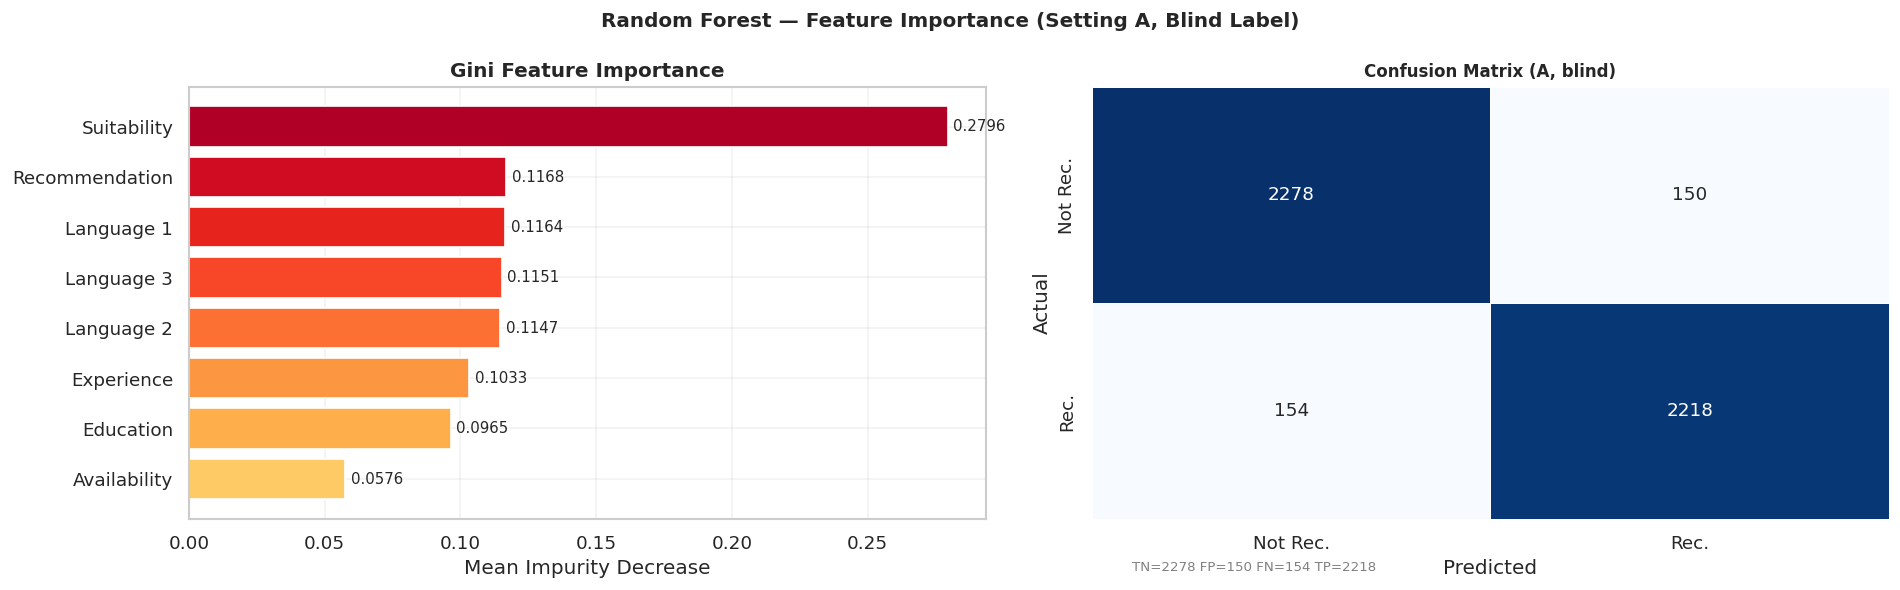

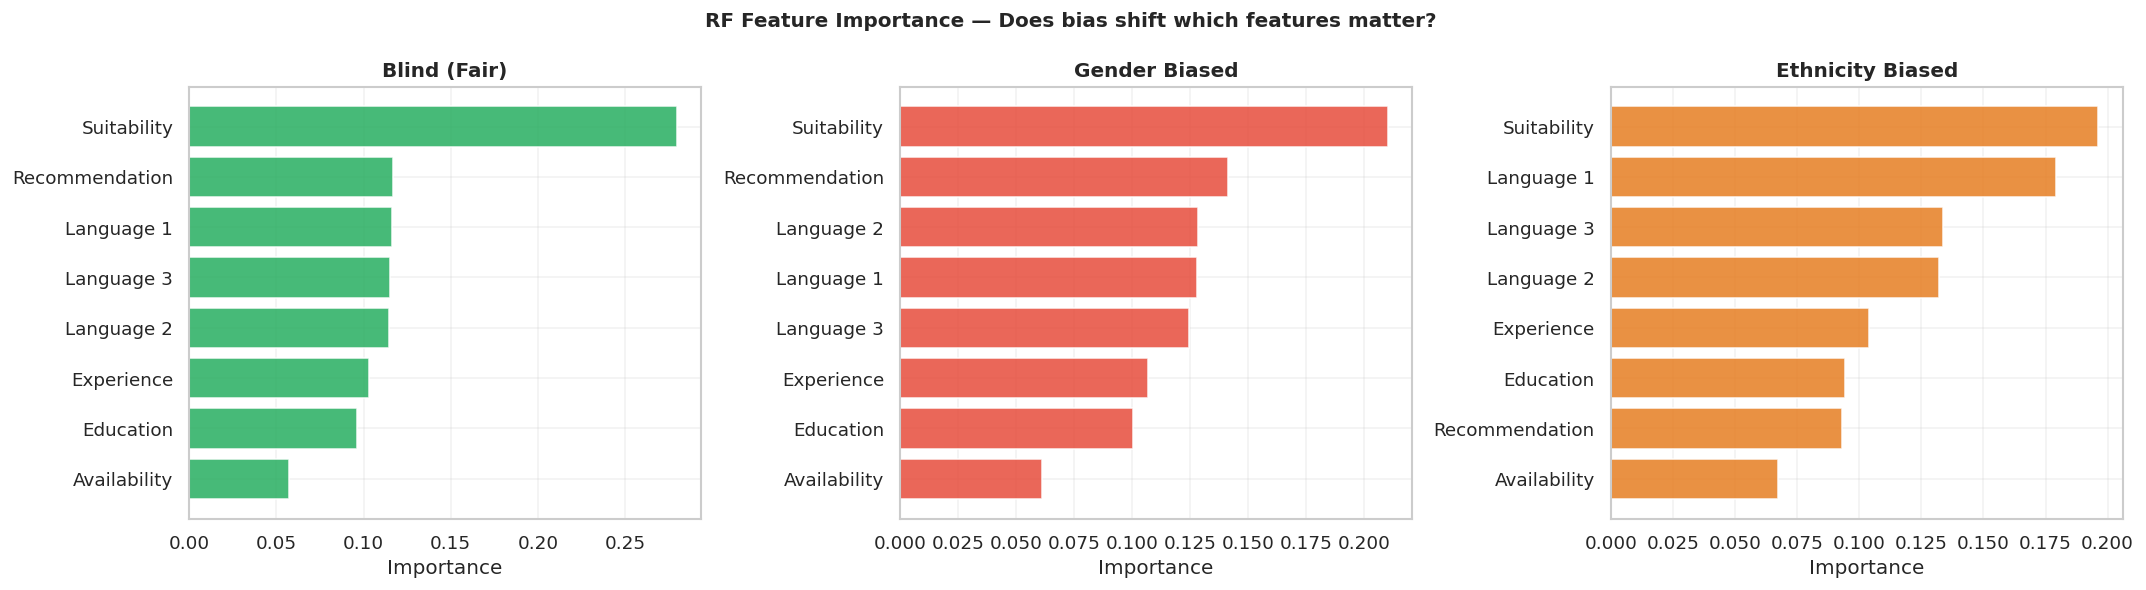

 If feature importance shifts between blind and biased labels,
 the model is learning different patterns — some may encode demographic proxies.


In [ ]:
# ── RF: Feature importance ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Random Forest — Feature Importance (Setting A, Blind Label)',
             fontsize=12, fontweight='bold')

# Gini importance
rf_A = rf_models['A: Competency Only | blind'][0]
fi   = pd.Series(rf_A.feature_importances_, index=COMP_NAMES).sort_values()
colors_fi = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(fi)))
bars = axes[0].barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
axes[0].set_title('Gini Feature Importance', fontweight='bold')
axes[0].set_xlabel('Mean Impurity Decrease')
for bar, val in zip(bars, fi.values):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Confusion matrix
_, _, y_te_A, y_pred_A, _ = rf_models['A: Competency Only | blind']
plot_confusion_matrix(y_te_A, y_pred_A, 'Confusion Matrix (A, blind)', axes[1])

plt.tight_layout()
plt.savefig('rf_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Feature importance: compare across labels (does bias change importance?)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RF Feature Importance — Does bias shift which features matter?',
             fontsize=12, fontweight='bold')

for ax, short, label_name in zip(axes, LABEL_SHORT,
    ['Blind (Fair)', 'Gender Biased', 'Ethnicity Biased']):
    rf_m = rf_models[f'A: Competency Only | {short}'][0]
    fi_m = pd.Series(rf_m.feature_importances_, index=COMP_NAMES).sort_values()
    ax.barh(fi_m.index, fi_m.values,
            color=PAL_LABEL[short], alpha=0.85, edgecolor='white')
    ax.set_title(label_name, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('rf_importance_by_label.png', bbox_inches='tight', dpi=150)
plt.show()
print(' If feature importance shifts between blind and biased labels,')
print(' the model is learning different patterns — some may encode demographic proxies.')

XAI-SHAP

sv shape: (4800, 8)


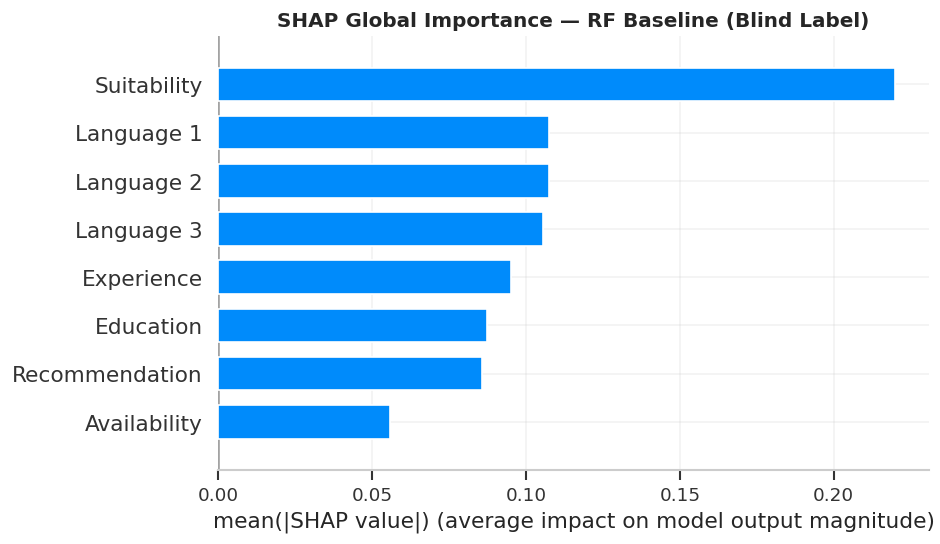

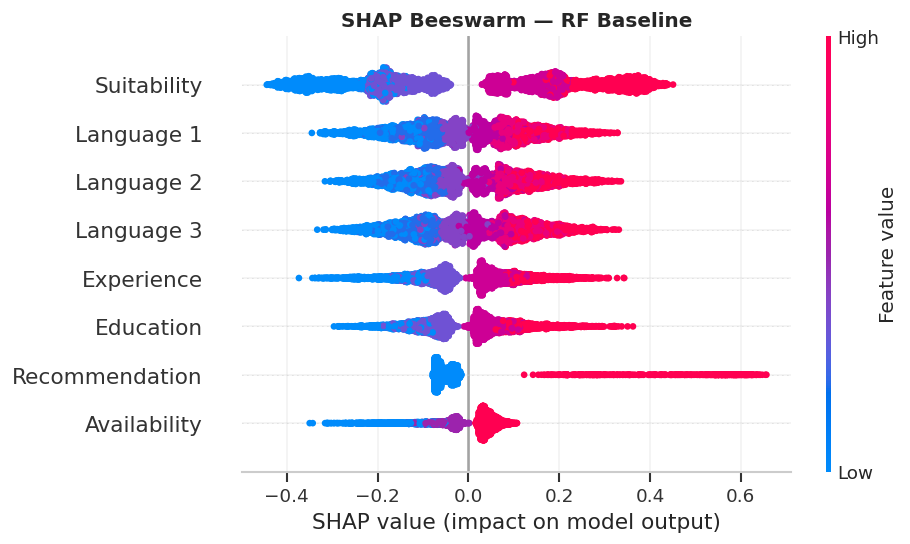

shap.summary_plot done


In [ ]:
# ════════════════════════════════════════════════════════════════════
# XAI Section 1 — SHAP Global (dùng shap.summary_plot gốc)
# ════════════════════════════════════════════════════════════════════
!pip install shap -q
import shap
import numpy as np

rf_A = rf_models['A: Competency Only | blind'][0]
_, X_te_A_raw, _, y_te_blind = get_split(COMPETENCY, 'y_blind', scale=False)

explainer_rf = shap.TreeExplainer(rf_A)
shap_values  = explainer_rf.shap_values(X_te_A_raw)

# ── FIX shape về (n_samples, n_features) cho class 1 ──
sv_arr = np.array(shap_values)
if sv_arr.ndim == 3:
    sv = sv_arr[:, :, 1]
elif isinstance(shap_values, list):
    sv = np.array(shap_values[1])
else:
    sv = sv_arr
print("sv shape:", sv.shape)   # phải (n, 8)
assert sv.shape[1] == len(COMP_NAMES)

# ── shap.summary_plot — BAR (global importance) ──────────────────────
shap.summary_plot(sv, X_te_A_raw, feature_names=COMP_NAMES,
                  plot_type='bar', show=False)
plt.title('SHAP Global Importance — RF Baseline (Blind Label)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── shap.summary_plot — BEESWARM (direction + magnitude) ─────────────
shap.summary_plot(sv, X_te_A_raw, feature_names=COMP_NAMES, show=False)
plt.title('SHAP Beeswarm — RF Baseline', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("shap.summary_plot done")

sv shape: (4800, 8) | features: 8


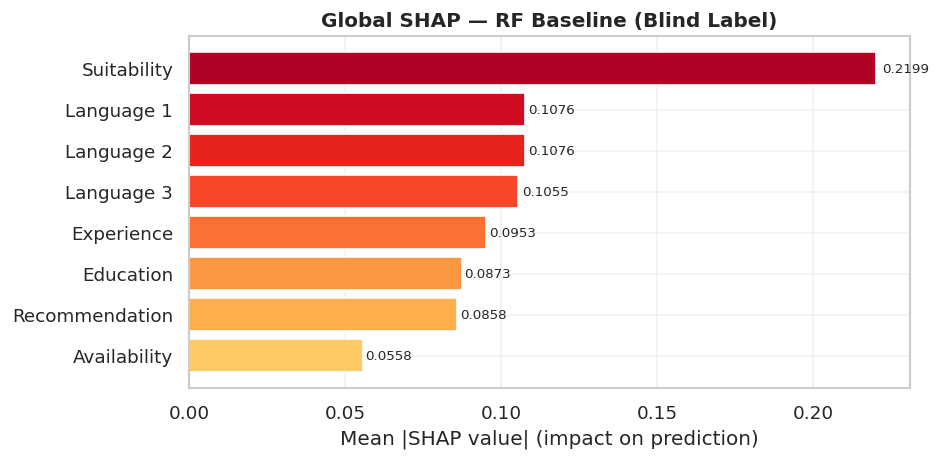

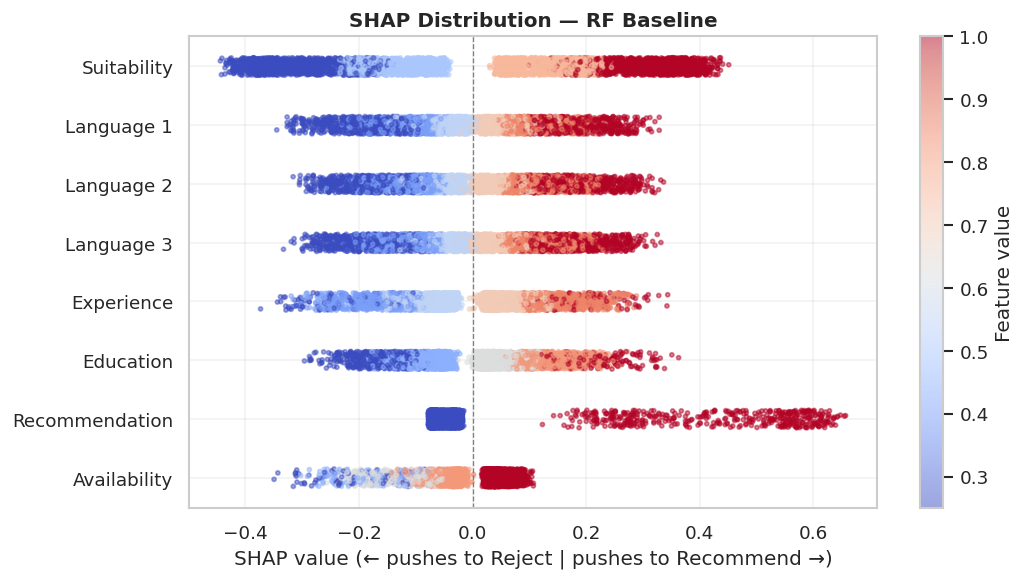

Section 1 done — 2 plots saved


In [ ]:
# ════════════════════════════════════════════════════════════════════
# XAI — SHAP Analysis (Global) — matplotlib thuần, kiểm soát hoàn toàn
# ════════════════════════════════════════════════════════════════════
import shap
import numpy as np
import matplotlib.pyplot as plt

rf_A = rf_models['A: Competency Only | blind'][0]
_, X_te_A_raw, _, y_te_blind = get_split(COMPETENCY, 'y_blind', scale=False)

explainer_rf = shap.TreeExplainer(rf_A)
shap_values  = explainer_rf.shap_values(X_te_A_raw)

# ── FIX shape: chuẩn hóa sv về (n_samples, n_features) cho class 1 ──
sv_arr = np.array(shap_values)
if sv_arr.ndim == 3:                       # (n, features, classes)
    sv = sv_arr[:, :, 1]
elif isinstance(shap_values, list):        # [class0, class1]
    sv = np.array(shap_values[1])
else:
    sv = sv_arr
print("sv shape:", sv.shape, "| features:", len(COMP_NAMES))
assert sv.shape[1] == len(COMP_NAMES), "Shape mismatch!"

# ── Plot 1: Global mean |SHAP| bar ───────────────────────────────────
mean_abs = np.abs(sv).mean(axis=0)
order    = np.argsort(mean_abs)
names_s  = [COMP_NAMES[i] for i in order]
vals_s   = mean_abs[order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names_s, vals_s, color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(vals_s))))
ax.set_xlabel('Mean |SHAP value| (impact on prediction)')
ax.set_title('Global SHAP — RF Baseline (Blind Label)', fontweight='bold')
for bar, v in zip(bars, vals_s):
    ax.text(v + v*0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('shap_global_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: SHAP value distribution (thay beeswarm) ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for i, idx in enumerate(order):
    vals = sv[:, idx]
    feat_vals = X_te_A_raw[:, idx]
    # màu theo feature value (cao=đỏ, thấp=xanh)
    sc = ax.scatter(vals, np.full_like(vals, i) + np.random.uniform(-0.15, 0.15, len(vals)),
                    c=feat_vals, cmap='coolwarm', s=6, alpha=0.5)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(names_s)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('SHAP value (← pushes to Reject | pushes to Recommend →)')
ax.set_title('SHAP Distribution — RF Baseline', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Feature value')
plt.tight_layout()
plt.savefig('shap_beeswarm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Section 1 done — 2 plots saved")

In [ ]:
# ── RF: Fairness analysis ────────────────────────────────────────────
print(' RF Fairness — Gender (Setting A, blind label):')
display(rf_fairness_g['A: Competency Only | blind'].round(4))
print('\n RF Fairness — Ethnicity (Setting A, blind label):')
display(rf_fairness_e['A: Competency Only | blind'].round(4))

 RF Fairness — Gender (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
Male,2437,0.9352,0.9349,0.4990,0.9372,0.0115,0.0043
Female,2363,0.9382,0.9369,0.4875,0.9329,0.0115,0.0043



 RF Fairness — Ethnicity (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
G1,1595,0.9361,0.9371,0.5078,0.9360,0.0218,0.0036
G2,1588,0.9377,0.9358,0.4861,0.9364,0.0218,0.0036
G3,1617,0.9363,0.9346,0.4861,0.9328,0.0218,0.0036


### 3.3. Multi-Layer Perceptron (MLP)

In [ ]:
# ====================================================================
# MULTI-LAYER PERCEPTRON (MLP)
#
# Why: Non-linear model that can capture complex feature interactions.
#      More expressive than LR; can model non-linear decision boundaries.
# Architecture: (8→64→32→1) — chosen to fit dataset size without overfitting.
# Scaling: Required (gradient-based optimizer sensitive to feature scale).
# Early stopping: monitors validation loss, restores best weights.
# Hyperparameter search: hidden layer size, learning rate, alpha.
# ====================================================================

print('=== MULTI-LAYER PERCEPTRON ===')
print('RandomizedSearchCV: 12 combinations × 3-fold CV...')

mlp_param_dist = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16), (32, 16)],
    'alpha':              [0.0001, 0.001, 0.01],        # L2 regularization
    'learning_rate_init': [0.001, 0.0005, 0.0001],
}

mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=200, early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=10, random_state=RANDOM_SEED, solver='adam'),
    param_distributions=mlp_param_dist,
    n_iter=12,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1', random_state=RANDOM_SEED, verbose=0
)
mlp_search.fit(X_tr_A, y_tr_blind)   # uses scaled features from Section 3
best_mlp_params = mlp_search.best_params_
print(f'Best params: {best_mlp_params}')
print(f'Best CV F1:  {mlp_search.best_score_:.4f}')

=== MULTI-LAYER PERCEPTRON ===
RandomizedSearchCV: 12 combinations × 3-fold CV...
Best params: {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (32, 16), 'alpha': 0.01}
Best CV F1:  0.9709


In [ ]:
# ===== Train MLP across all settings × all labels =====
mlp_results    = {}
mlp_fairness_g = {}
mlp_fairness_e = {}
mlp_models     = {}
mlp_loss_curves= {}

for setting_name, feat_cols in FEATURE_SETS.items():
    for label_col, short in zip(['y_blind','y_gender','y_ethnicity'], LABEL_SHORT):
        key = f'{setting_name} | {short}'
        X_tr, X_te, y_tr, y_te = get_split(feat_cols, label_col, scale=True)

        mlp = MLPClassifier(
            **best_mlp_params,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=RANDOM_SEED,
            solver='adam'
        )
        mlp.fit(X_tr, y_tr)
        y_pred = mlp.predict(X_te)
        y_prob = mlp.predict_proba(X_te)[:, 1]

        mlp_results[key]     = compute_metrics(y_te, y_pred, y_prob)
        mlp_fairness_g[key]  = compute_group_metrics(y_te, y_pred, gender_te,    GENDER_LABELS)
        mlp_fairness_e[key]  = compute_group_metrics(y_te, y_pred, ethnicity_te, ETH_LABELS)
        mlp_models[key]      = (mlp, feat_cols, y_te, y_pred, y_prob)
        mlp_loss_curves[key] = mlp.loss_curve_

mlp_perf_df = pd.DataFrame(mlp_results).T.round(4)
print(' MLP — Performance Table:')
display(mlp_perf_df)

 MLP — Performance Table:


,Accuracy,Precision,Recall,F1,ROC-AUC
A: Competency Only | blind,0.9654,0.9642,0.9659,0.9650,0.9964
A: Competency Only | gender,0.8698,0.8189,0.8259,0.8224,0.9569
A: Competency Only | ethnicity,0.8315,0.8272,0.8318,0.8295,0.9238
B: Competency + Demographics | blind,0.9648,0.9661,0.9625,0.9643,0.9965
B: Competency + Demographics | gender,0.9617,0.9490,0.9458,0.9474,0.9953
B: Competency + Demographics | ethnicity,0.9702,0.9744,0.9649,0.9696,0.9969
C: Competency + Face Emb | blind,0.9602,0.9599,0.9595,0.9597,0.9956
C: Competency + Face Emb | gender,0.9212,0.9003,0.8818,0.8910,0.9790
C: Competency + Face Emb | ethnicity,0.8931,0.8885,0.8956,0.8920,0.9636
D: Competency + Blind Emb | blind,0.9627,0.9625,0.9621,0.9623,0.9958


In [ ]:
# ===== MLP: Fairness =====
print(' MLP Fairness — Gender (Setting A, blind label):')
display(mlp_fairness_g['A: Competency Only | blind'].round(4))
print('\n MLP Fairness — Ethnicity (Setting A, blind label):')
display(mlp_fairness_e['A: Competency Only | blind'].round(4))

 MLP Fairness — Gender (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
Male,2437,0.9651,0.9649,0.4969,0.9653,0.0039,0.0011
Female,2363,0.9657,0.9652,0.4930,0.9664,0.0039,0.0011



 MLP Fairness — Ethnicity (Setting A, blind label):


,N,Accuracy,F1,Pos Rate,True Pos Rate,DP Gap,EOO Gap
Group,,,,,,,
G1,1595,0.9661,0.9666,0.5053,0.9631,0.0198,0.0053
G2,1588,0.9673,0.9663,0.4855,0.9663,0.0198,0.0053
G3,1617,0.9629,0.9622,0.4941,0.9683,0.0198,0.0053


### 3.4 Cross-Model Comparison

In [ ]:
# ====================================================================
# CROSS-MODEL COMPARISON
#
# Combines results from LR, RF, MLP into a unified performance table
# and fairness table — enabling direct apples-to-apples comparison.
# ====================================================================

# ===== Build master comparison dataframe =====
all_records = []
for model_name, perf_dict, fair_g, fair_e in [
    ('LR',  lr_results,  lr_fairness_g,  lr_fairness_e),
    ('RF',  rf_results,  rf_fairness_g,  rf_fairness_e),
    ('MLP', mlp_results, mlp_fairness_g, mlp_fairness_e),
]:
    for key, metrics in perf_dict.items():
        parts = key.split(' | ')
        setting = parts[0].split(':')[0].strip()  # A/B/C/D
        label   = parts[1]
        rec = {'Model': model_name, 'Setting': setting, 'Label': label}
        rec.update({k: round(v, 4) for k, v in metrics.items()})
        rec['DP_Gap_Gender']    = round(fair_g[key]['DP Gap'].mean(), 4)
        rec['EOO_Gap_Gender']   = round(fair_g[key]['EOO Gap'].mean(), 4)
        rec['DP_Gap_Ethnicity'] = round(fair_e[key]['DP Gap'].mean(), 4)
        rec['EOO_Gap_Eth']      = round(fair_e[key]['EOO Gap'].mean(), 4)
        all_records.append(rec)

master_df = pd.DataFrame(all_records)

print(' Master Comparison Table (Setting A, all labels):')
display(master_df[master_df['Setting']=='A'].sort_values(['Label','Model']))

print('\n Master Comparison Table (blind label, all settings):')
display(master_df[master_df['Label']=='blind'].sort_values(['Setting','Model']))

 Master Comparison Table (Setting A, all labels):


,Model,Setting,Label,Accuracy,Precision,Recall,F1,ROC-AUC,DP_Gap_Gender,EOO_Gap_Gender,DP_Gap_Ethnicity,EOO_Gap_Eth
0,LR,A,blind,0.9665,0.9734,0.9583,0.9658,0.9966,0.0046,0.0008,0.0230,0.0075
24,MLP,A,blind,0.9654,0.9642,0.9659,0.9650,0.9964,0.0039,0.0011,0.0198,0.0053
12,RF,A,blind,0.9367,0.9367,0.9351,0.9359,0.9866,0.0115,0.0043,0.0218,0.0036
2,LR,A,ethnicity,0.8233,0.8176,0.8259,0.8217,0.9182,0.0029,0.0110,0.1158,0.2782
26,MLP,A,ethnicity,0.8315,0.8272,0.8318,0.8295,0.9238,0.0115,0.0008,0.1363,0.2725
14,RF,A,ethnicity,0.8040,0.7955,0.8107,0.8030,0.8878,0.0042,0.0162,0.1191,0.2468
1,LR,A,gender,0.8638,0.8381,0.7768,0.8063,0.9572,0.0038,0.3205,0.0174,0.0202
25,MLP,A,gender,0.8698,0.8189,0.8259,0.8224,0.9569,0.0066,0.2521,0.0140,0.0259
13,RF,A,gender,0.8538,0.8140,0.7768,0.7950,0.9353,0.0043,0.2590,0.0234,0.0538



 Master Comparison Table (blind label, all settings):


,Model,Setting,Label,Accuracy,Precision,Recall,F1,ROC-AUC,DP_Gap_Gender,EOO_Gap_Gender,DP_Gap_Ethnicity,EOO_Gap_Eth
0,LR,A,blind,0.9665,0.9734,0.9583,0.9658,0.9966,0.0046,0.0008,0.0230,0.0075
24,MLP,A,blind,0.9654,0.9642,0.9659,0.9650,0.9964,0.0039,0.0011,0.0198,0.0053
12,RF,A,blind,0.9367,0.9367,0.9351,0.9359,0.9866,0.0115,0.0043,0.0218,0.0036
3,LR,B,blind,0.9665,0.9734,0.9583,0.9658,0.9966,0.0038,0.0025,0.0224,0.0050
27,MLP,B,blind,0.9648,0.9661,0.9625,0.9643,0.9965,0.0077,0.0010,0.0179,0.0057
15,RF,B,blind,0.9346,0.9313,0.9368,0.9340,0.9865,0.0072,0.0059,0.0223,0.0088
6,LR,C,blind,0.9648,0.9685,0.9599,0.9642,0.9965,0.0061,0.0026,0.0211,0.0036
30,MLP,C,blind,0.9602,0.9599,0.9595,0.9597,0.9956,0.0044,0.0017,0.0205,0.0062
18,RF,C,blind,0.9077,0.8997,0.9153,0.9074,0.9759,0.0024,0.0092,0.0242,0.0094
9,LR,D,blind,0.9656,0.9710,0.9591,0.9650,0.9965,0.0045,0.0009,0.0236,0.0062


****  ***

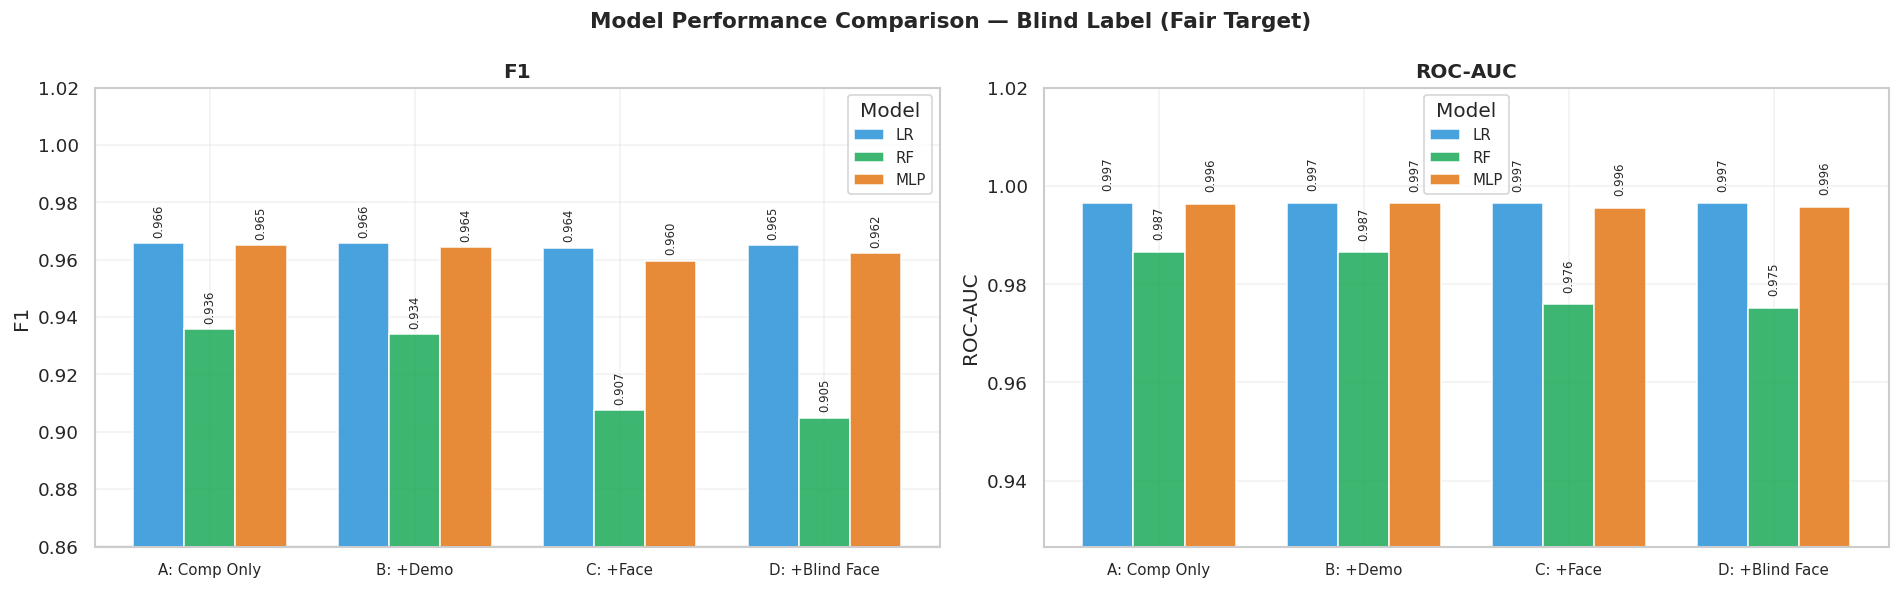

In [ ]:
# ===== Performance bar chart — all models × settings × blind label =====
blind_df = master_df[master_df['Label']=='blind'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Performance Comparison — Blind Label (Fair Target)',
             fontsize=13, fontweight='bold')

metrics_to_plot = ['F1', 'ROC-AUC']
for ax, metric in zip(axes, metrics_to_plot):
    pivot = blind_df.pivot(index='Setting', columns='Model', values=metric)
    x = np.arange(len(pivot))
    w = 0.25
    for i, (model, color) in enumerate(PAL_MODEL.items()):
        if model in pivot.columns:
            bars = ax.bar(x + (i-1)*w, pivot[model], w,
                          label=model, color=color, edgecolor='white', alpha=0.9)
            for bar, val in zip(bars, pivot[model]):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.003, f'{val:.3f}',
                        ha='center', fontsize=7, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(['A: Comp Only','B: +Demo','C: +Face','D: +Blind Face'],
                       fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(blind_df[metric].min()*0.95, 1.02)
    ax.legend(title='Model', fontsize=9)

plt.tight_layout()
plt.savefig('compare_perf.png', bbox_inches='tight', dpi=150)
plt.show()

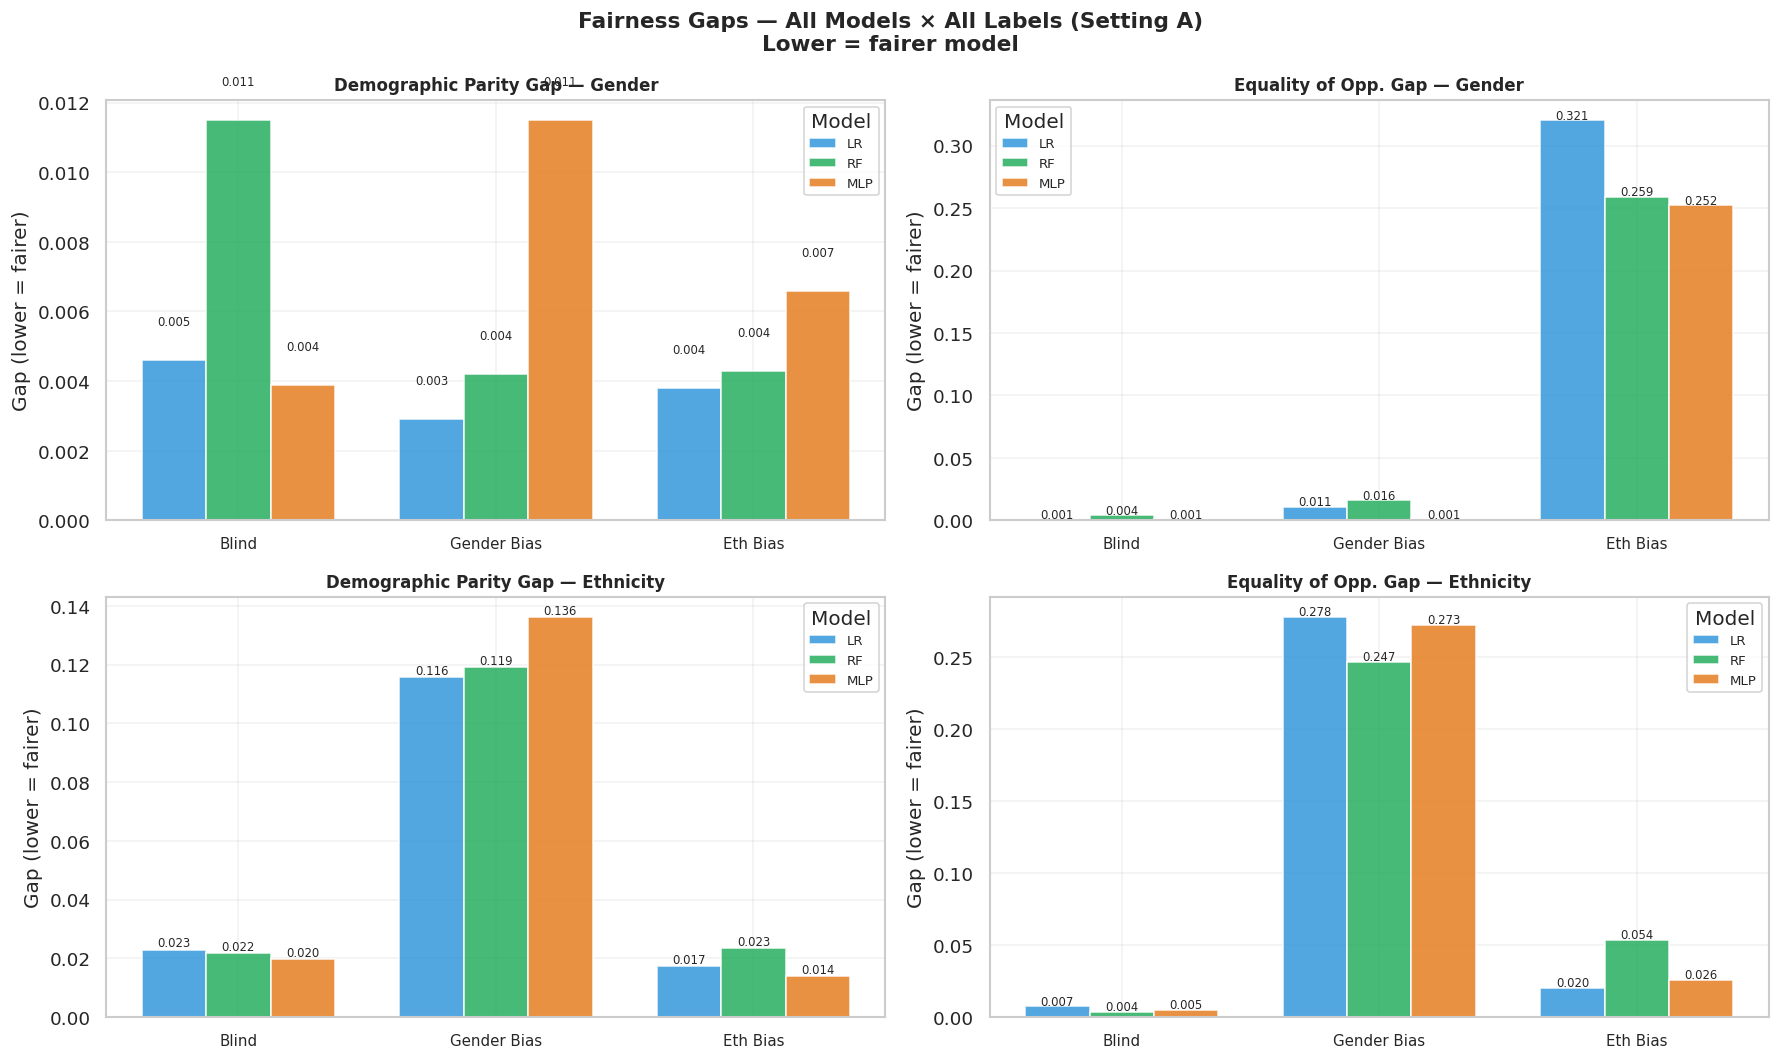

In [ ]:
# ===== Fairness comparison — all models, Setting A =====
settingA_df = master_df[master_df['Setting']=='A'].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Fairness Gaps — All Models × All Labels (Setting A)\n'
             'Lower = fairer model',
             fontsize=13, fontweight='bold')

fairness_metrics = [
    ('DP_Gap_Gender',    'Demographic Parity Gap — Gender'),
    ('EOO_Gap_Gender',   'Equality of Opp. Gap — Gender'),
    ('DP_Gap_Ethnicity', 'Demographic Parity Gap — Ethnicity'),
    ('EOO_Gap_Eth',      'Equality of Opp. Gap — Ethnicity'),
]

for ax, (fm, title) in zip(axes.flat, fairness_metrics):
    pivot = settingA_df.pivot(index='Label', columns='Model', values=fm)
    x = np.arange(len(pivot))
    w = 0.25
    for i, (model, color) in enumerate(PAL_MODEL.items()):
        if model in pivot.columns:
            bars = ax.bar(x + (i-1)*w, pivot[model], w,
                          label=model, color=color, edgecolor='white', alpha=0.85)
            for bar, val in zip(bars, pivot[model]):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.001, f'{val:.3f}',
                        ha='center', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Blind','Gender Bias','Eth Bias'], fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Gap (lower = fairer)')
    ax.legend(title='Model', fontsize=8)

plt.tight_layout()
plt.savefig('compare_fairness.png', bbox_inches='tight', dpi=150)
plt.show()

 Overfitting Analysis (Setting A, blind label):


,Model,CV F1 Mean,CV F1 Std,Test F1,Gap
0,LR,0.9714,0.0021,0.9658,0.0056
1,RF,0.9413,0.0036,0.9359,0.0054
2,MLP,0.9705,0.0006,0.9650,0.0054


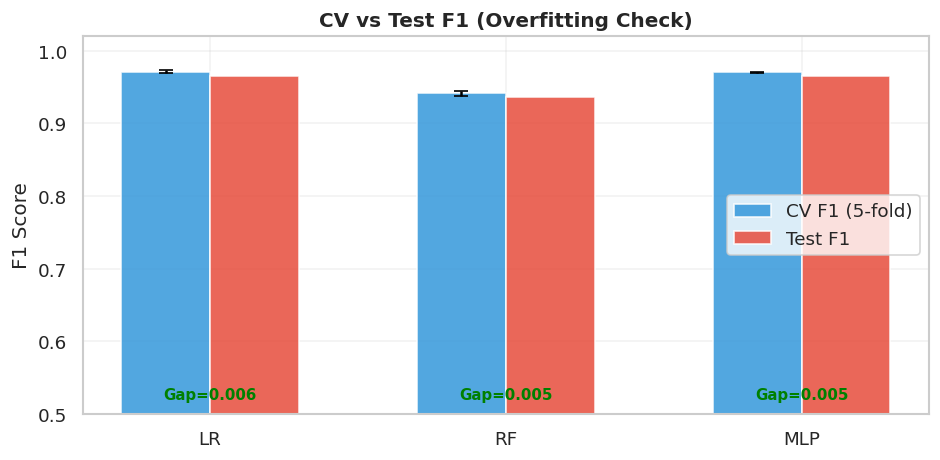

In [ ]:
# ===== Overfitting analysis: cross-validation score vs test score =====
# If CV score >> test score = overfitting; if similar = well-generalized.

overfit_rows = []
X_tr_A_raw, X_te_A_raw, y_tr, y_te = get_split(COMPETENCY, 'y_blind', scale=False)
X_tr_A_sc,  X_te_A_sc,  _,    _    = get_split(COMPETENCY, 'y_blind', scale=True)

for model_name, estimator, X_tr, X_te in [
    ('LR',  LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_SEED), X_tr_A_sc,  X_te_A_sc),
    ('RF',  RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1), X_tr_A_raw, X_te_A_raw),
    ('MLP', MLPClassifier(**best_mlp_params, max_iter=300, early_stopping=True,
                           n_iter_no_change=15, random_state=RANDOM_SEED), X_tr_A_sc, X_te_A_sc),
]:
    cv_scores = cross_val_score(estimator, X_tr, y_tr,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
                                 scoring='f1', n_jobs=-1)
    estimator.fit(X_tr, y_tr)
    test_f1 = f1_score(y_te, estimator.predict(X_te))
    overfit_rows.append({'Model': model_name,
                          'CV F1 Mean': cv_scores.mean(),
                          'CV F1 Std':  cv_scores.std(),
                          'Test F1':    test_f1,
                          'Gap':        cv_scores.mean() - test_f1})

overfit_df = pd.DataFrame(overfit_rows)
print(' Overfitting Analysis (Setting A, blind label):')
display(overfit_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); w = 0.3
ax.bar(x - w/2, overfit_df['CV F1 Mean'], w, label='CV F1 (5-fold)',
       color='#3498DB', edgecolor='white', alpha=0.85)
ax.bar(x + w/2, overfit_df['Test F1'],    w, label='Test F1',
       color='#E74C3C', edgecolor='white', alpha=0.85)
ax.errorbar(x - w/2, overfit_df['CV F1 Mean'],
            yerr=overfit_df['CV F1 Std'], fmt='none', color='black', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(overfit_df['Model'])
ax.set_ylabel('F1 Score'); ax.set_title('CV vs Test F1 (Overfitting Check)', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.02)
for i, row in overfit_df.iterrows():
    color = 'red' if row['Gap'] > 0.05 else 'green'
    ax.text(i, 0.52, f'Gap={row["Gap"]:.3f}', ha='center', fontsize=9, color=color, fontweight='bold')
plt.tight_layout()
plt.savefig('overfitting.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.5 Deep Fairness Analysis

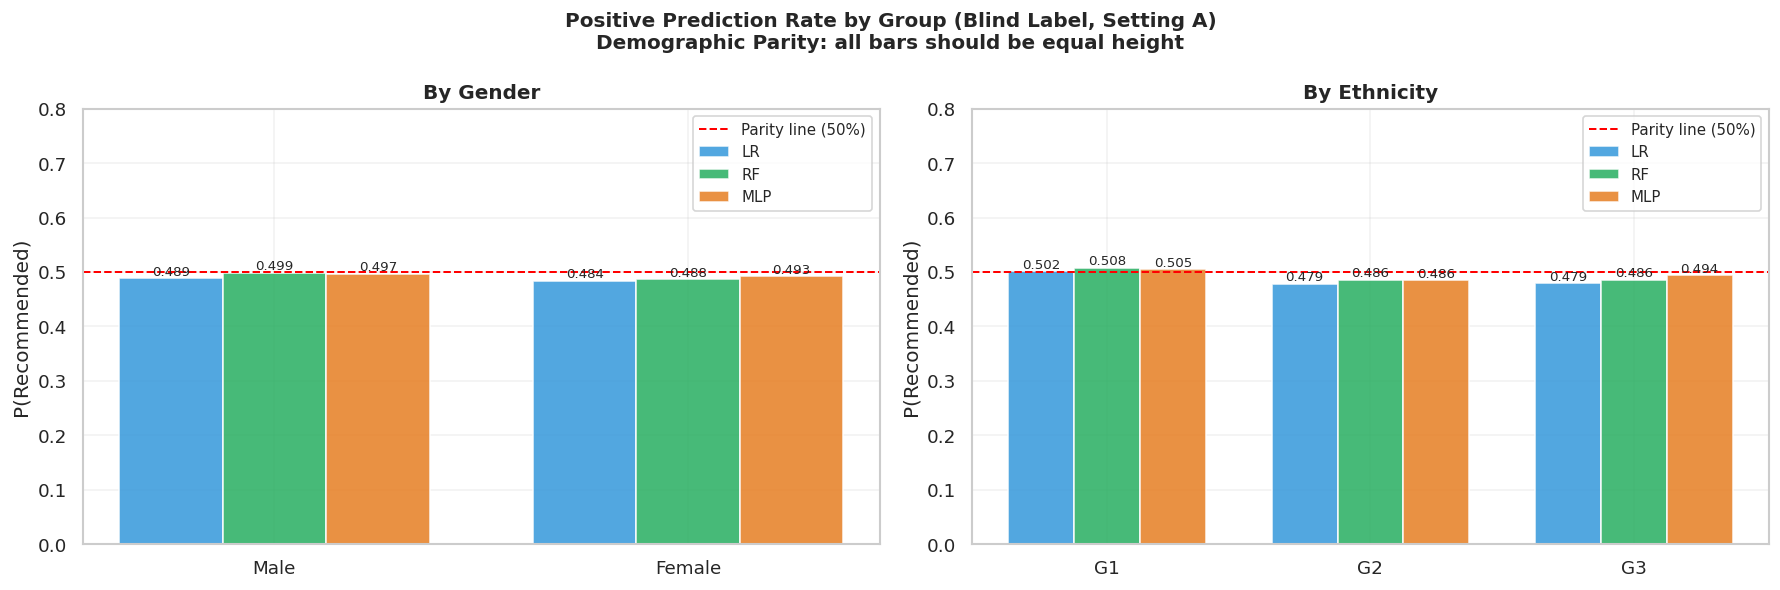

 If bars are unequal within a group cluster = demographic disparity.
 Trained on blind_label: bars should be nearly equal — confirming fair label.


In [ ]:
# ===== Positive prediction rate by group — all models (blind label) =====
# Demographic Parity: P(ŷ=1|group=g) should be equal across groups

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Positive Prediction Rate by Group (Blind Label, Setting A)\n'
             'Demographic Parity: all bars should be equal height',
             fontsize=12, fontweight='bold')

for ax, (demo_arr, demo_labels, demo_title) in zip(axes, [
    (gender_te,    GENDER_LABELS, 'Gender'),
    (ethnicity_te, ETH_LABELS,    'Ethnicity'),
]):
    groups   = list(demo_labels.values())
    x        = np.arange(len(groups))
    w        = 0.25

    for i, (model_name, color, models_dict) in enumerate([
        ('LR',  PAL_MODEL['LR'],  lr_models),
        ('RF',  PAL_MODEL['RF'],  rf_models),
        ('MLP', PAL_MODEL['MLP'], mlp_models),
    ]):
        key = 'A: Competency Only | blind'
        _, _, _, y_pred, _ = models_dict[key]
        pos_rates = [y_pred[demo_arr == gid].mean() for gid in demo_labels]
        bars = ax.bar(x + (i-1)*w, pos_rates, w, label=model_name,
                      color=color, edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, pos_rates):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005, f'{val:.3f}',
                    ha='center', fontsize=8)

    ax.axhline(0.5, color='red', linestyle='--', lw=1.2,
               label='Parity line (50%)')
    ax.set_xticks(x); ax.set_xticklabels(groups)
    ax.set_title(f'By {demo_title}', fontweight='bold')
    ax.set_ylabel('P(Recommended)')
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fairness_pos_rate.png', bbox_inches='tight', dpi=150)
plt.show()
print(' If bars are unequal within a group cluster = demographic disparity.')
print(' Trained on blind_label: bars should be nearly equal — confirming fair label.')

In [ ]:
# ===== Impact of demographic features (Setting B) on fairness =====
# When we ADD gender/ethnicity as features (Setting B),
# does the model learn to discriminate using them?

print(' Fairness: Does adding demographics (Setting B) increase bias?')
print()

comparison_rows = []
for model_name, fair_g, fair_e in [
    ('LR',  lr_fairness_g,  lr_fairness_e),
    ('RF',  rf_fairness_g,  rf_fairness_e),
    ('MLP', mlp_fairness_g, mlp_fairness_e),
]:
    for label_short in LABEL_SHORT:
        key_A = f'A: Competency Only | {label_short}'
        key_B = f'B: Competency + Demographics | {label_short}'
        dp_A  = fair_g[key_A]['DP Gap'].mean()
        dp_B  = fair_g[key_B]['DP Gap'].mean()
        comparison_rows.append({
            'Model': model_name, 'Label': label_short,
            'DP Gap (A)': round(dp_A, 4),
            'DP Gap (B)': round(dp_B, 4),
            'Change': round(dp_B - dp_A, 4),
            'Direction': '⬆ More biased' if dp_B > dp_A else '⬇ Less biased'
        })

comp_df = pd.DataFrame(comparison_rows)
print('Setting A (no demographics) vs Setting B (with demographics):')
display(comp_df)
print('\n If DP Gap increases from A→B: adding demographics made the model more biased.')
print('   This is the PROXY BIAS effect: model explicitly uses demographic features.')

 Fairness: Does adding demographics (Setting B) increase bias?

Setting A (no demographics) vs Setting B (with demographics):


,Model,Label,DP Gap (A),DP Gap (B),Change,Direction
0,LR,blind,0.0046,0.0038,-0.0008,⬇ Less biased
1,LR,gender,0.0038,0.2648,0.2610,⬆ More biased
2,LR,ethnicity,0.0029,0.0179,0.0150,⬆ More biased
3,RF,blind,0.0115,0.0072,-0.0043,⬇ Less biased
4,RF,gender,0.0043,0.2790,0.2747,⬆ More biased
5,RF,ethnicity,0.0042,0.0210,0.0168,⬆ More biased
6,MLP,blind,0.0039,0.0077,0.0038,⬆ More biased
7,MLP,gender,0.0066,0.2680,0.2614,⬆ More biased
8,MLP,ethnicity,0.0115,0.0255,0.0139,⬆ More biased



 If DP Gap increases from A→B: adding demographics made the model more biased.
   This is the PROXY BIAS effect: model explicitly uses demographic features.


---
## 3.6 Summary & Recommendations

In [ ]:
# ════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════

# Best model per metric (blind label, Setting A)
best_rows = []
for model_name, fair_g, fair_e, models_dict in [
    ('LR',  lr_fairness_g,  lr_fairness_e,  lr_models),
    ('RF',  rf_fairness_g,  rf_fairness_e,  rf_models),
    ('MLP', mlp_fairness_g, mlp_fairness_e, mlp_models),
]:
    key = 'A: Competency Only | blind'
    _, _, y_te, y_pred, y_prob = models_dict[key]
    best_rows.append({
        'Model':              model_name,
        'Accuracy':           round(accuracy_score(y_te, y_pred), 4),
        'F1':                 round(f1_score(y_te, y_pred), 4),
        'ROC-AUC':            round(roc_auc_score(y_te, y_prob), 4),
        'Gender DP Gap':      round(fair_g[key]['DP Gap'].mean(), 4),
        'Gender EOO Gap':     round(fair_g[key]['EOO Gap'].mean(), 4),
        'Ethnicity DP Gap':   round(fair_e[key]['DP Gap'].mean(), 4),
        'Ethnicity EOO Gap':  round(fair_e[key]['EOO Gap'].mean(), 4),
    })

final_df = pd.DataFrame(best_rows).set_index('Model')
print('=' * 70)
print('  FINAL MODEL COMPARISON — Setting A (Competency Only), Blind Label')
print('=' * 70)
display(final_df)

best_acc   = final_df['F1'].idxmax()
best_fair  = final_df['Gender DP Gap'].idxmin()
worst_fair = final_df['Gender DP Gap'].idxmax()

print(f'\n Best F1 Score:          {best_acc}  ({final_df.loc[best_acc,"F1"]:.4f})')
print(f' Fairest (Gender DP Gap): {best_fair}  ({final_df.loc[best_fair,"Gender DP Gap"]:.4f})')
print(f' Most Biased:             {worst_fair} ({final_df.loc[worst_fair,"Gender DP Gap"]:.4f})')

  FINAL MODEL COMPARISON — Setting A (Competency Only), Blind Label


,Accuracy,F1,ROC-AUC,Gender DP Gap,Gender EOO Gap,Ethnicity DP Gap,Ethnicity EOO Gap
Model,,,,,,,
LR,0.9665,0.9658,0.9966,0.0046,0.0008,0.0230,0.0075
RF,0.9367,0.9359,0.9866,0.0115,0.0043,0.0218,0.0036
MLP,0.9654,0.9650,0.9964,0.0039,0.0011,0.0198,0.0053



 Best F1 Score:          LR  (0.9658)
 Fairest (Gender DP Gap): MLP  (0.0039)
 Most Biased:             RF (0.0115)


---
## 4. Multimodal Fusion (SBERT)

 ### 4.1 SBERT Text Encoding  

In [ ]:
# ====================================================================
# Sentence-BERT Text Encoding
# Input  : df['bio_anonymized'] — gender-blinded biographies
#          (sử dụng bio_anonymized thay vì bio_original để tránh
#           gender pronoun leakage — (proposal Section 12.2)
# Output : text_embeddings shape (24000, 384)
# ==================================================================
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading Sentence-BERT model: all-MiniLM-L6-v2 ...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# ===== Sử dụng bio_anonymized (đã ẩn gender indicators) =====
bio_texts = df['bio_anonymized'].fillna('').tolist()

print(f"Encoding {len(bio_texts):,} biographies...")
text_embeddings = sbert_model.encode(
    bio_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f" SBERT encoding complete.")
print(f" Embedding shape: {text_embeddings.shape}")  # (24000, 384)
print(f" Sample embedding norm: {np.linalg.norm(text_embeddings[0]):.4f}")

# ===== Lưu để tái sử dụng nếu cần restart =====
np.save('sbert_embeddings.npy', text_embeddings)
print(" Saved to: sbert_embeddings.npy")

Loading Sentence-BERT model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 24,000 biographies...


Batches:   0%|          | 0/375 [00:00<?, ?it/s]

 SBERT encoding complete.
 Embedding shape: (24000, 384)
 Sample embedding norm: 1.0000
 Saved to: sbert_embeddings.npy


 ### 4.2 Feature Stream Separation

In [ ]:
# ===================================================================
# Feature Stream Separation
#
# Tách thành 2 feature streams theo Proposal Section 8.2:
#   Stream 1 — Text features    : SBERT embeddings (384-dim)
#   Stream 2 — Structured/Meta  : 8 competency features
#
# Sử dụng đúng cách notebook tách split (df['split'] == 'train/test')
# Tái sử dụng get_split() từ Cell 6 cho Stream 2 — tránh data leakage
# Tái sử dụng gender_te, ethnicity_te từ Cell 6 — không định nghĩa lại
# ====================================================================

from sklearn.preprocessing import StandardScaler

# ===== Tạo boolean mask dựa trên cột split đã có trong df (Cell 4) =====
is_train = (df['split'] == 'train').values   # shape (24000,), dtype bool
is_test  = (df['split'] == 'test').values    # shape (24000,), dtype bool

# ===== Stream 1: Text features từ SBERT (Cell 42) =====
# text_embeddings có shape (24000, 384), cùng thứ tự với df
X_text_tr = text_embeddings[is_train]   # (19200, 384)
X_text_te = text_embeddings[is_test]    # (4800,  384)

# ===== Normalize text embeddings — fit trên train only, transform test =====
text_scaler  = StandardScaler()
X_text_tr    = text_scaler.fit_transform(X_text_tr)
X_text_te    = text_scaler.transform(X_text_te)

# ===== Stream 2: Structured features (8 competency features) =====
# Tái sử dụng get_split() từ Cell 6 — đã xử lý scaling + data leakage
# scale=True: StandardScaler fit trên train only
X_struct_tr, X_struct_te, y_tr_fusion, y_te_fusion = get_split(
    COMPETENCY, 'y_blind', scale=True
)
# y_tr_fusion, y_te_fusion = binary blind label (fair target)

# ===== Kiểm tra =====
# gender_te, ethnicity_te đã có từ Cell 6 — dùng trực tiếp trong fusion
assert X_text_tr.shape[0] == X_struct_tr.shape[0] == len(y_tr_fusion), \
    "Train size mismatch!"
assert X_text_te.shape[0] == X_struct_te.shape[0] == len(y_te_fusion), \
    "Test size mismatch!"

print("  Feature streams ready:")
print(f"   [Train] Text  : {X_text_tr.shape}  | Structured: {X_struct_tr.shape}")
print(f"   [Test]  Text  : {X_text_te.shape}   | Structured: {X_struct_te.shape}")
print(f"   Labels  — Train: {y_tr_fusion.shape} | Test: {y_te_fusion.shape}")
print(f"   Class balance  — Train 1s: {y_tr_fusion.mean()*100:.1f}% "
      f"| Test 1s: {y_te_fusion.mean()*100:.1f}%")

  Feature streams ready:
   [Train] Text  : (19200, 384)  | Structured: (19200, 8)
   [Test]  Text  : (4800, 384)   | Structured: (4800, 8)
   Labels  — Train: (19200,) | Test: (4800,)
   Class balance  — Train 1s: 50.1% | Test 1s: 49.4%


 ### 4.3 Early Fusion  

In [ ]:
# =====================================================================
# EARLY FUSION
# Proposal Section 8.4, 10.2:
#   F_early = [E_text ; E_meta]   (concatenation)
#   ŷ = f(F_early)
#
# Concatenate text (384-dim) + structured (8-dim) → 392-dim input
# Train LR, RF, MLP trên fused feature vector.
# ======================================================================

import numpy as np

print("=" * 60)
print("  EARLY FUSION")
print("  F_early = [SBERT_text ; Structured_features]")
print(f"  Input dim: {X_text_tr.shape[1]} + {X_struct_tr.shape[1]} = "
      f"{X_text_tr.shape[1] + X_struct_tr.shape[1]}")
print("=" * 60)

# ===== Concatenate feature vectors =====
X_early_tr = np.concatenate([X_text_tr, X_struct_tr], axis=1)  # (19200, 392)
X_early_te = np.concatenate([X_text_te, X_struct_te], axis=1)  # (4800, 392)

early_results    = {}
early_fairness_g = {}
early_fairness_e = {}
early_models     = {}

# ===== Classifiers (tái sử dụng best params từ cells trước) =====
fusion_classifiers = {
    'LR':  LogisticRegression(C=best_C, max_iter=1000,
                               random_state=RANDOM_SEED, solver='lbfgs'),
    'RF':  RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED),
    'MLP': MLPClassifier(**best_mlp_params, random_state=RANDOM_SEED,
                          early_stopping=True, validation_fraction=0.1),
}

for name, clf in fusion_classifiers.items():
    print(f"\n  Training Early Fusion — {name}...")
    t0 = time.time()

    clf.fit(X_early_tr, y_tr_fusion)
    y_pred = clf.predict(X_early_te)
    y_prob = clf.predict_proba(X_early_te)[:, 1]

    early_results[name]    = compute_metrics(y_te_fusion, y_pred, y_prob)
    early_fairness_g[name] = compute_group_metrics(
        y_te_fusion, y_pred, gender_te, GENDER_LABELS)
    early_fairness_e[name] = compute_group_metrics(
        y_te_fusion, y_pred, ethnicity_te, ETH_LABELS)
    early_models[name]     = (clf, y_pred, y_prob)

    m = early_results[name]
    print(f"    F1={m['F1']:.4f} | AUC={m['ROC-AUC']:.4f} | "
          f"Acc={m['Accuracy']:.4f} | "
          f"DP_Gender={early_fairness_g[name]['DP Gap'].mean():.4f} | "
          f"DP_Eth={early_fairness_e[name]['DP Gap'].mean():.4f} | "
          f"Time={time.time()-t0:.1f}s")

print("\n Early Fusion — Performance Summary:")
early_df = pd.DataFrame(early_results).T.round(4)
display(early_df)

  EARLY FUSION
  F_early = [SBERT_text ; Structured_features]
  Input dim: 384 + 8 = 392

  Training Early Fusion — LR...
    F1=0.9632 | AUC=0.9960 | Acc=0.9637 | DP_Gender=0.0074 | DP_Eth=0.0205 | Time=1.2s

  Training Early Fusion — RF...
    F1=0.8141 | AUC=0.9033 | Acc=0.8087 | DP_Gender=0.0019 | DP_Eth=0.0472 | Time=134.1s

  Training Early Fusion — MLP...
    F1=0.9331 | AUC=0.9876 | Acc=0.9346 | DP_Gender=0.0058 | DP_Eth=0.0268 | Time=7.6s

 Early Fusion — Performance Summary:


,Accuracy,Precision,Recall,F1,ROC-AUC
LR,0.9638,0.9665,0.9599,0.9632,0.9960
RF,0.8088,0.7833,0.8474,0.8141,0.9033
MLP,0.9346,0.9432,0.9233,0.9331,0.9876


 ### 4.4 Late Fusion   

In [ ]:
# =====================================================================
# LATE FUSION
# Proposal Section 8.4, 10.3:
#   ŷ_text = f1(E_text)
#   ŷ_meta = f2(E_meta)
#   P = β * P_text + (1-β) * P_meta
#
# 2 models hoàn toàn độc lập cho mỗi modality.
# Kết hợp output probabilities bằng weighted average.
# β = 0.5 (equal weight) theo proposal default.
#
# Tái sử dụng: best_C, best_rf_params, best_mlp_params từ cells trước.
# Lưu trữ: late_models[name] = (y_pred, y_prob) — tuple 2 phần tử
#           (khác với lr_models/rf_models/mlp_models tuple 5 phần tử)
# ========================================================================

BETA = 0.5   # β trong Proposal Section 10.3: P = β*P_text + (1-β)*P_meta

print("=" * 60)
print("  LATE FUSION — P = β·P_text + (1-β)·P_structured")
print(f"  β = {BETA} | Classifiers: LR, RF, MLP")
print("=" * 60)

late_results    = {}
late_fairness_g = {}
late_fairness_e = {}
late_models     = {}   # key → (y_pred, y_prob)

for clf_name in ['LR', 'RF', 'MLP']:

    # ===== Khởi tạo 2 instances riêng biệt cho text và structured =====
    if clf_name == 'LR':
        clf_text   = LogisticRegression(
                         C=best_C, max_iter=1000,
                         random_state=RANDOM_SEED, solver='lbfgs')
        clf_struct = LogisticRegression(
                         C=best_C, max_iter=1000,
                         random_state=RANDOM_SEED, solver='lbfgs')

    elif clf_name == 'RF':
        # best_rf_params chứa: n_estimators, max_depth,
        # min_samples_leaf, max_features — không có n_jobs
        clf_text   = RandomForestClassifier(
                         **best_rf_params,
                         random_state=RANDOM_SEED, n_jobs=-1)
        clf_struct = RandomForestClassifier(
                         **best_rf_params,
                         random_state=RANDOM_SEED, n_jobs=-1)

    else:  # MLP
        # best_mlp_params chứa: hidden_layer_sizes, alpha, learning_rate_init
        clf_text   = MLPClassifier(
                         **best_mlp_params,
                         max_iter=300, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=15,
                         random_state=RANDOM_SEED, solver='adam')
        clf_struct = MLPClassifier(
                         **best_mlp_params,
                         max_iter=300, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=15,
                         random_state=RANDOM_SEED, solver='adam')

    print(f"\n  [{clf_name}] Training text model  ...", end=" ")
    t0 = time.time()
    clf_text.fit(X_text_tr, y_tr_fusion)
    P_text = clf_text.predict_proba(X_text_te)[:, 1]
    print(f"done ({time.time()-t0:.1f}s)")

    print(f"  [{clf_name}] Training struct model...", end=" ")
    t0 = time.time()
    clf_struct.fit(X_struct_tr, y_tr_fusion)
    P_struct = clf_struct.predict_proba(X_struct_te)[:, 1]
    print(f"done ({time.time()-t0:.1f}s)")

    # ===== Late fusion: P = β*P_text + (1-β)*P_struct =====
    P_combined = BETA * P_text + (1 - BETA) * P_struct
    y_pred     = (P_combined >= 0.5).astype(int)

    late_results[clf_name]    = compute_metrics(y_te_fusion, y_pred, P_combined)
    late_fairness_g[clf_name] = compute_group_metrics(
        y_te_fusion, y_pred, gender_te, GENDER_LABELS)
    late_fairness_e[clf_name] = compute_group_metrics(
        y_te_fusion, y_pred, ethnicity_te, ETH_LABELS)

    # ===== Lưu tuple (y_pred, y_prob) — nhất quán trong toàn bộ fusion cells =====
    late_models[clf_name] = (y_pred, P_combined)

    m = late_results[clf_name]
    print(f"  [{clf_name}] F1={m['F1']:.4f} | AUC={m['ROC-AUC']:.4f} | "
          f"Acc={m['Accuracy']:.4f} | Prec={m['Precision']:.4f} | "
          f"Rec={m['Recall']:.4f}")
    print(f"         DP_Gender={late_fairness_g[clf_name]['DP Gap'].mean():.4f} | "
          f"EOO_Gender={late_fairness_g[clf_name]['EOO Gap'].mean():.4f} | "
          f"DP_Eth={late_fairness_e[clf_name]['DP Gap'].mean():.4f}")

print("\n Late Fusion — Performance Summary:")
display(pd.DataFrame(late_results).T.round(4))

  LATE FUSION — P = β·P_text + (1-β)·P_structured
  β = 0.5 | Classifiers: LR, RF, MLP

  [LR] Training text model  ... done (1.4s)
  [LR] Training struct model... done (0.1s)
  [LR] F1=0.9606 | AUC=0.9880 | Acc=0.9610 | Prec=0.9596 | Rec=0.9616
         DP_Gender=0.0035 | EOO_Gender=0.0027 | DP_Eth=0.0217

  [RF] Training text model  ... done (101.4s)
  [RF] Training struct model... done (2.0s)
  [RF] F1=0.9252 | AUC=0.9774 | Acc=0.9254 | Prec=0.9171 | Rec=0.9334
         DP_Gender=0.0137 | EOO_Gender=0.0044 | DP_Eth=0.0200

  [MLP] Training text model  ... done (2.6s)
  [MLP] Training struct model... done (1.8s)
  [MLP] F1=0.9542 | AUC=0.9890 | Acc=0.9546 | Prec=0.9503 | Rec=0.9583
         DP_Gender=0.0080 | EOO_Gender=0.0008 | DP_Eth=0.0143

 Late Fusion — Performance Summary:


,Accuracy,Precision,Recall,F1,ROC-AUC
LR,0.9610,0.9596,0.9616,0.9606,0.9880
RF,0.9254,0.9171,0.9334,0.9252,0.9774
MLP,0.9546,0.9503,0.9583,0.9542,0.9890


### 4.5 Hybrid Fusion

In [ ]:
# ====================================================================
# WEIGHTED HYBRID FUSION
#
# Proposal Section 8.4, 10.4:
#   F = α * F_text + (1-α) * F_meta
#
# Feature-level weighted combination.
# Cần alignment về dimension: dùng PCA để project text (384-dim)
# xuống cùng dimension với structured (8-dim).
# α = 0.6 (text-dominant) — hypothesis: biography mang nhiều
# thông tin hơn 8 structured features.
# =====================================================================

from sklearn.decomposition import PCA

print("=" * 60)
print("  WEIGHTED HYBRID FUSION")
print("  F = α * F_text_reduced + (1-α) * F_structured")
print("  α = 0.6 | PCA for dimensionality alignment")
print("=" * 60)

ALPHA = 0.6   # Proposal Section 10.4

# ===== PCA: project text embeddings → same dim as structured =====
n_struct = X_struct_tr.shape[1]   # = 8

pca = PCA(n_components=n_struct, random_state=RANDOM_SEED)
X_text_tr_pca = pca.fit_transform(X_text_tr)   # (19200, 8)
X_text_te_pca = pca.transform(X_text_te)        # (4800, 8)

print(f"  PCA variance explained: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}% "
      f"({n_struct} components from 384-dim)")

# ===== Weighted feature combination =====
X_hybrid_tr = ALPHA * X_text_tr_pca + (1 - ALPHA) * X_struct_tr
X_hybrid_te = ALPHA * X_text_te_pca + (1 - ALPHA) * X_struct_te

hybrid_results    = {}
hybrid_fairness_g = {}
hybrid_fairness_e = {}
hybrid_models     = {}

fusion_classifiers_h = {
    'LR':  LogisticRegression(C=best_C, max_iter=1000,
                               random_state=RANDOM_SEED),
    'RF':  RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED),
    'MLP': MLPClassifier(**best_mlp_params, random_state=RANDOM_SEED,
                          early_stopping=True, validation_fraction=0.1),
}

for name, clf in fusion_classifiers_h.items():
    print(f"\n  Training Weighted Hybrid Fusion — {name}...")
    t0 = time.time()

    clf.fit(X_hybrid_tr, y_tr_fusion)
    y_pred = clf.predict(X_hybrid_te)
    y_prob = clf.predict_proba(X_hybrid_te)[:, 1]

    hybrid_results[name]    = compute_metrics(y_te_fusion, y_pred, y_prob)
    hybrid_fairness_g[name] = compute_group_metrics(
        y_te_fusion, y_pred, gender_te, GENDER_LABELS)
    hybrid_fairness_e[name] = compute_group_metrics(
        y_te_fusion, y_pred, ethnicity_te, ETH_LABELS)
    hybrid_models[name]     = (clf, y_pred, y_prob)

    m = hybrid_results[name]
    print(f"    F1={m['F1']:.4f} | AUC={m['ROC-AUC']:.4f} | "
          f"DP_Gender={hybrid_fairness_g[name]['DP Gap'].mean():.4f} | "
          f"DP_Eth={hybrid_fairness_e[name]['DP Gap'].mean():.4f} | "
          f"Time={time.time()-t0:.1f}s")

print("\n Hybrid Fusion — Performance Summary:")
hybrid_df = pd.DataFrame(hybrid_results).T.round(4)
display(hybrid_df)

  WEIGHTED HYBRID FUSION
  F = α * F_text_reduced + (1-α) * F_structured
  α = 0.6 | PCA for dimensionality alignment
  PCA variance explained: 26.2% (8 components from 384-dim)

  Training Weighted Hybrid Fusion — LR...
    F1=0.6807 | AUC=0.7366 | DP_Gender=0.0386 | DP_Eth=0.0507 | Time=0.1s

  Training Weighted Hybrid Fusion — RF...
    F1=0.6920 | AUC=0.7500 | DP_Gender=0.0240 | DP_Eth=0.0379 | Time=15.8s

  Training Weighted Hybrid Fusion — MLP...
    F1=0.6993 | AUC=0.7571 | DP_Gender=0.0425 | DP_Eth=0.0490 | Time=4.2s

 Hybrid Fusion — Performance Summary:


,Accuracy,Precision,Recall,F1,ROC-AUC
LR,0.6754,0.6623,0.7003,0.6807,0.7366
RF,0.6912,0.6824,0.7019,0.6920,0.7500
MLP,0.6927,0.6771,0.7230,0.6993,0.7571


### 4.6 Extended Fairness (DI)   

In [ ]:
# ===================================================================
# Extended Fairness: Thêm Disparate Impact
#
# Proposal Section 13.2:
#   DI = P(ŷ=1|A=1) / P(ŷ=1|A=0)
#   DI < 0.8 → potential discrimination (4/5 rule)
# Bổ sung DI vào kết quả của TẤT CẢ experiments.
# ===================================================================

def compute_disparate_impact(y_pred, sensitive_attr):
    """
    Disparate Impact = min_group_rate / max_group_rate
    Proposal Section 13.2: DI = P(ŷ=1|A=1) / P(ŷ=1|A=0)
    DI < 0.8 → potential disparate impact (EEOC 4/5 rule)
    """
    groups = np.unique(sensitive_attr)
    rates  = {g: y_pred[sensitive_attr == g].mean() for g in groups}
    max_r  = max(rates.values())
    min_r  = min(rates.values())
    di     = min_r / max_r if max_r > 0 else 1.0
    return round(di, 4), rates


def compute_full_fairness(y_true, y_pred, gender_arr, ethnicity_arr):
    """Tổng hợp DP Gap, EOO Gap, Disparate Impact cho cả gender và ethnicity."""
    g_df  = compute_group_metrics(y_true, y_pred, gender_arr, GENDER_LABELS)
    e_df  = compute_group_metrics(y_true, y_pred, ethnicity_arr, ETH_LABELS)
    di_g, g_rates = compute_disparate_impact(y_pred, gender_arr)
    di_e, e_rates = compute_disparate_impact(y_pred, ethnicity_arr)

    return {
        'DP_Gap_Gender':    round(g_df['DP Gap'].mean(), 4),
        'EOO_Gap_Gender':   round(g_df['EOO Gap'].mean(), 4),
        'DI_Gender':        di_g,
        'DP_Gap_Ethnicity': round(e_df['DP Gap'].mean(), 4),
        'EOO_Gap_Ethnicity':round(e_df['EOO Gap'].mean(), 4),
        'DI_Ethnicity':     di_e,
    }


# ===== Tính full fairness cho tất cả fusion experiments =====
print("Computing full fairness metrics (DP, EOO, DI) for all fusion strategies...\n")

fusion_fairness_full = {}

for fusion_name, results_dict, models_dict in [
    ('Early Fusion',   early_results,  early_models),
    ('Late Fusion',    late_results,   late_models),
    ('Hybrid Fusion',  hybrid_results, hybrid_models),
]:
    for clf_name in ['LR', 'RF', 'MLP']:
        key = f"{fusion_name} | {clf_name}"
        if fusion_name == 'Late Fusion':
            y_pred, _ = models_dict[clf_name]
        else:
            _, y_pred, _ = models_dict[clf_name]

        fusion_fairness_full[key] = compute_full_fairness(
            y_te_fusion, y_pred, gender_te, ethnicity_te
        )

fusion_fairness_df = pd.DataFrame(fusion_fairness_full).T.round(4)
print(" Full Fairness Table ─ All Fusion Strategies:")
display(fusion_fairness_df)
print("\n DI < 0.8 indicates potential disparate impact (4/5 rule)")
print(f"   Gender DI violations: "
      f"{(fusion_fairness_df['DI_Gender'] < 0.8).sum()} / {len(fusion_fairness_df)}")
print(f"   Ethnicity DI violations: "
      f"{(fusion_fairness_df['DI_Ethnicity'] < 0.8).sum()} / {len(fusion_fairness_df)}")

Computing full fairness metrics (DP, EOO, DI) for all fusion strategies...

 Full Fairness Table ─ All Fusion Strategies:


,DP_Gap_Gender,EOO_Gap_Gender,DI_Gender,DP_Gap_Ethnicity,EOO_Gap_Ethnicity,DI_Ethnicity
Early Fusion | LR,0.0074,0.0058,0.9851,0.0205,0.0033,0.9594
Early Fusion | RF,0.0019,0.0056,0.9965,0.0472,0.0335,0.9155
Early Fusion | MLP,0.0058,0.0138,0.9882,0.0268,0.0024,0.9465
Late Fusion | LR,0.0035,0.0027,0.9930,0.0217,0.0119,0.9571
Late Fusion | RF,0.0137,0.0044,0.9732,0.0200,0.0206,0.9611
Late Fusion | MLP,0.0080,0.0008,0.9841,0.0143,0.0169,0.9717
Hybrid Fusion | LR,0.0386,0.0275,0.9288,0.0507,0.0354,0.9079
Hybrid Fusion | RF,0.0240,0.0293,0.9539,0.0379,0.0214,0.9280
Hybrid Fusion | MLP,0.0425,0.0335,0.9226,0.0490,0.0283,0.9122



 DI < 0.8 indicates potential disparate impact (4/5 rule)
   Gender DI violations: 0 / 9
   Ethnicity DI violations: 0 / 9


---
## 5. Research Questions Analysis

### RQ1+RQ2: Fusion Comparison

  MASTER FUSION COMPARISON 

 Predictive Performance by Fusion Strategy:


Accuracy  Precision  Recall        F1  \
Fusion Strategy            Classifier                                          
Baseline (Structured Only) LR            0.9665     0.9734  0.9583  0.965800   
                           MLP           0.9654     0.9642  0.9659  0.965000   
                           RF            0.9367     0.9367  0.9351  0.935900   
Early Fusion               LR            0.9637     0.9665  0.9599  0.963198   
                           MLP           0.9346     0.9432  0.9233  0.933106   
                           RF            0.8087     0.7833  0.8474  0.814095   
Late Fusion                LR            0.9610     0.9596  0.9616  0.960623   
                           MLP           0.9546     0.9503  0.9583  0.954240   
                           RF            0.9254     0.9171  0.9334  0.925198   
Weighted Hybrid Fusion     LR            0.6754     0.6623  0.7003  0.680738   
                           MLP           0.6927     0.6771  0.7230  0.699286   
                           RF            0.6913     0.6824  0.7019  0.692020   

                                        ROC-AUC  
Fusion Strategy            Classifier            
Baseline (Structured Only) LR          0.996600  
                           MLP         0.996400  
                           RF          0.986600  
Early Fusion               LR          0.995973  
                           MLP         0.987565  
                           RF          0.903340  
Late Fusion                LR          0.988030  
                           MLP         0.988962  
                           RF          0.977410  
Weighted Hybrid Fusion     LR          0.736642  
                           MLP         0.757100  
                           RF          0.750049


 Fairness by Fusion Strategy:


DP_Gap_Gender  EOO_Gap_Gender  \
Fusion Strategy            Classifier                                  
Baseline (Structured Only) LR                 0.0046          0.0008   
                           MLP                0.0039          0.0011   
                           RF                 0.0115          0.0043   
Early Fusion               LR                 0.0074          0.0058   
                           MLP                0.0058          0.0138   
                           RF                 0.0019          0.0056   
Late Fusion                LR                 0.0035          0.0027   
                           MLP                0.0080          0.0008   
                           RF                 0.0137          0.0044   
Weighted Hybrid Fusion     LR                 0.0386          0.0275   
                           MLP                0.0425          0.0335   
                           RF                 0.0240          0.0293   

                                       DI_Gender  DP_Gap_Ethnicity  \
Fusion Strategy            Classifier                                
Baseline (Structured Only) LR             0.9906            0.0230   
                           MLP            0.9921            0.0198   
                           RF             0.9770            0.0218   
Early Fusion               LR             0.9851            0.0205   
                           MLP            0.9882            0.0268   
                           RF             0.9965            0.0472   
Late Fusion                LR             0.9930            0.0217   
                           MLP            0.9841            0.0143   
                           RF             0.9732            0.0200   
Weighted Hybrid Fusion     LR             0.9288            0.0507   
                           MLP            0.9226            0.0490   
                           RF             0.9539            0.0379   

                                       EOO_Gap_Ethnicity  DI_Ethnicity  
Fusion Strategy            Classifier                                   
Baseline (Structured Only) LR                     0.0075        0.9542  
                           MLP                    0.0053        0.9608  
                           RF                     0.0036        0.9572  
Early Fusion               LR                     0.0033        0.9594  
                           MLP                    0.0024        0.9465  
                           RF                     0.0335        0.9155  
Late Fusion                LR                     0.0119        0.9571  
                           MLP                    0.0169        0.9717  
                           RF                     0.0206        0.9611  
Weighted Hybrid Fusion     LR                     0.0354        0.9079  
                           MLP                    0.0283        0.9122  
                           RF                     0.0214        0.9280


 Best F1 per Strategy:


,Fusion Strategy,Best F1
0,Baseline (Structured Only),0.965800
1,Early Fusion,0.963198
2,Late Fusion,0.960623
3,Weighted Hybrid Fusion,0.699286



 Lowest DP Gap Gender per Strategy:


,Fusion Strategy,Min DP Gap Gender
0,Early Fusion,0.0019
1,Late Fusion,0.0035
2,Baseline (Structured Only),0.0039
3,Weighted Hybrid Fusion,0.0240



  Disparate Impact violations (DI < 0.8, EEOC 4/5 rule):
   Gender    : 0 / 12 experiments
   Ethnicity : 0 / 12 experiments


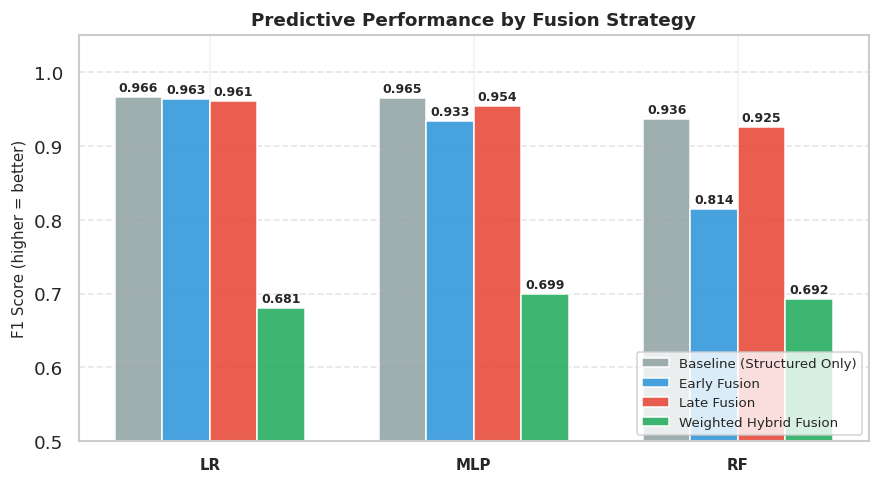

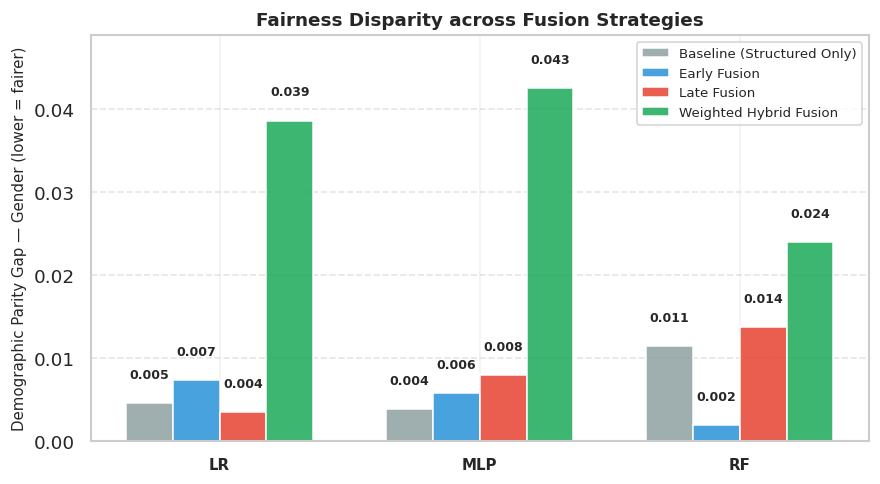

In [ ]:
print("=" * 70)
print("  MASTER FUSION COMPARISON ")
print("=" * 70)

# ── Helper: tính Disparate Impact ────────────────────────────────────
def compute_di(y_pred, sensitive_arr):
    """
    DI = min_group_rate / max_group_rate
    DI < 0.8 → potential disparate impact (EEOC 4/5 rule)
    Proposal Section 13.2
    """
    groups = np.unique(sensitive_arr)
    rates  = {g: y_pred[sensitive_arr == g].mean() for g in groups}
    max_r  = max(rates.values())
    min_r  = min(rates.values())
    return round(min_r / max_r, 4) if max_r > 0 else 1.0


fusion_records = []

# ════════════════════════════════════════════════════════════════════
# PHẦN 1: Baseline — Setting A (Competency Only, blind label)
# Lấy từ lr_models/rf_models/mlp_models (Cell 11/17/23)
# Tuple structure: (model, feat_cols, y_te, y_pred, y_prob) → index 3,4
# ════════════════════════════════════════════════════════════════════
baseline_key = 'A: Competency Only | blind'

for clf_name, models_dict, fair_g_dict, fair_e_dict in [
    ('LR',  lr_models,  lr_fairness_g,  lr_fairness_e),
    ('RF',  rf_models,  rf_fairness_g,  rf_fairness_e),
    ('MLP', mlp_models, mlp_fairness_g, mlp_fairness_e),
]:
    _, _, y_te_b, y_pred_b, y_prob_b = models_dict[baseline_key]

    fusion_records.append({
        'Fusion Strategy': 'Baseline (Structured Only)',
        'Classifier':      clf_name,
        'Accuracy':   round(accuracy_score(y_te_b, y_pred_b), 4),
        'Precision':  round(precision_score(y_te_b, y_pred_b, zero_division=0), 4),
        'Recall':     round(recall_score(y_te_b, y_pred_b, zero_division=0), 4),
        'F1':         round(f1_score(y_te_b, y_pred_b, zero_division=0), 4),
        'ROC-AUC':    round(roc_auc_score(y_te_b, y_prob_b), 4),
        'DP_Gap_Gender':     round(fair_g_dict[baseline_key]['DP Gap'].mean(), 4),
        'EOO_Gap_Gender':    round(fair_g_dict[baseline_key]['EOO Gap'].mean(), 4),
        'DI_Gender':         compute_di(y_pred_b, gender_te),
        'DP_Gap_Ethnicity':  round(fair_e_dict[baseline_key]['DP Gap'].mean(), 4),
        'EOO_Gap_Ethnicity': round(fair_e_dict[baseline_key]['EOO Gap'].mean(), 4),
        'DI_Ethnicity':      compute_di(y_pred_b, ethnicity_te),
    })

# ════════════════════════════════════════════════════════════════════
# PHẦN 2: Early Fusion
# Tuple structure: (clf, y_pred, y_prob) → index 1, 2
# ════════════════════════════════════════════════════════════════════
for clf_name in ['LR', 'RF', 'MLP']:
    _, y_pred_e, y_prob_e = early_models[clf_name]

    fusion_records.append({
        'Fusion Strategy': 'Early Fusion',
        'Classifier':      clf_name,
        'Accuracy':   round(accuracy_score(y_te_fusion, y_pred_e), 4),
        'Precision':  round(precision_score(y_te_fusion, y_pred_e, zero_division=0), 4),
        'Recall':     round(recall_score(y_te_fusion, y_pred_e, zero_division=0), 4),
        'F1':         early_results[clf_name]['F1'],
        'ROC-AUC':    early_results[clf_name]['ROC-AUC'],
        'DP_Gap_Gender':     round(early_fairness_g[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Gender':    round(early_fairness_g[clf_name]['EOO Gap'].mean(), 4),
        'DI_Gender':         compute_di(y_pred_e, gender_te),
        'DP_Gap_Ethnicity':  round(early_fairness_e[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Ethnicity': round(early_fairness_e[clf_name]['EOO Gap'].mean(), 4),
        'DI_Ethnicity':      compute_di(y_pred_e, ethnicity_te),
    })

# ════════════════════════════════════════════════════════════════════
# PHẦN 3: Late Fusion
# Tuple structure: (y_pred, y_prob) → index 0, 1
# ════════════════════════════════════════════════════════════════════
for clf_name in ['LR', 'RF', 'MLP']:
    y_pred_l, y_prob_l = late_models[clf_name]

    fusion_records.append({
        'Fusion Strategy': 'Late Fusion',
        'Classifier':      clf_name,
        'Accuracy':   round(accuracy_score(y_te_fusion, y_pred_l), 4),
        'Precision':  round(precision_score(y_te_fusion, y_pred_l, zero_division=0), 4),
        'Recall':     round(recall_score(y_te_fusion, y_pred_l, zero_division=0), 4),
        'F1':         late_results[clf_name]['F1'],
        'ROC-AUC':    late_results[clf_name]['ROC-AUC'],
        'DP_Gap_Gender':     round(late_fairness_g[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Gender':    round(late_fairness_g[clf_name]['EOO Gap'].mean(), 4),
        'DI_Gender':         compute_di(y_pred_l, gender_te),
        'DP_Gap_Ethnicity':  round(late_fairness_e[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Ethnicity': round(late_fairness_e[clf_name]['EOO Gap'].mean(), 4),
        'DI_Ethnicity':      compute_di(y_pred_l, ethnicity_te),
    })

# ════════════════════════════════════════════════════════════════════
# PHẦN 4: Weighted Hybrid Fusion
# Tuple structure: (clf, y_pred, y_prob) → index 1, 2
# ════════════════════════════════════════════════════════════════════
for clf_name in ['LR', 'RF', 'MLP']:
    _, y_pred_h, y_prob_h = hybrid_models[clf_name]

    fusion_records.append({
        'Fusion Strategy': 'Weighted Hybrid Fusion',
        'Classifier':      clf_name,
        'Accuracy':   round(accuracy_score(y_te_fusion, y_pred_h), 4),
        'Precision':  round(precision_score(y_te_fusion, y_pred_h, zero_division=0), 4),
        'Recall':     round(recall_score(y_te_fusion, y_pred_h, zero_division=0), 4),
        'F1':         hybrid_results[clf_name]['F1'],
        'ROC-AUC':    hybrid_results[clf_name]['ROC-AUC'],
        'DP_Gap_Gender':     round(hybrid_fairness_g[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Gender':    round(hybrid_fairness_g[clf_name]['EOO Gap'].mean(), 4),
        'DI_Gender':         compute_di(y_pred_h, gender_te),
        'DP_Gap_Ethnicity':  round(hybrid_fairness_e[clf_name]['DP Gap'].mean(), 4),
        'EOO_Gap_Ethnicity': round(hybrid_fairness_e[clf_name]['EOO Gap'].mean(), 4),
        'DI_Ethnicity':      compute_di(y_pred_h, ethnicity_te),
    })

# ── Build DataFrame ───────────────────────────────────────────────────
fusion_master_df = pd.DataFrame(fusion_records)

# ── Hiển thị RQ1: Predictive Performance ─────────────────────────────
print("\n Predictive Performance by Fusion Strategy:")
perf_cols = ['Fusion Strategy', 'Classifier',
             'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
display(fusion_master_df[perf_cols]
        .sort_values(['Fusion Strategy', 'Classifier'])
        .set_index(['Fusion Strategy', 'Classifier']))

# ── Hiển thị RQ2: Fairness ───────────────────────────────────────────
print("\n Fairness by Fusion Strategy:")
fair_cols = ['Fusion Strategy', 'Classifier',
             'DP_Gap_Gender', 'EOO_Gap_Gender', 'DI_Gender',
             'DP_Gap_Ethnicity', 'EOO_Gap_Ethnicity', 'DI_Ethnicity']
display(fusion_master_df[fair_cols]
        .sort_values(['Fusion Strategy', 'Classifier'])
        .set_index(['Fusion Strategy', 'Classifier']))

# ── Summary answers ───────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" Best F1 per Strategy:")
print("=" * 70)
rq1 = (fusion_master_df
       .groupby('Fusion Strategy')['F1']
       .max()
       .sort_values(ascending=False)
       .reset_index())
rq1.columns = ['Fusion Strategy', 'Best F1']
display(rq1)

print("\n" + "=" * 70)
print(" Lowest DP Gap Gender per Strategy:")
print("=" * 70)
rq2 = (fusion_master_df
       .groupby('Fusion Strategy')['DP_Gap_Gender']
       .min()
       .sort_values()
       .reset_index())
rq2.columns = ['Fusion Strategy', 'Min DP Gap Gender']
display(rq2)

di_violations_g = (fusion_master_df['DI_Gender'] < 0.8).sum()
di_violations_e = (fusion_master_df['DI_Ethnicity'] < 0.8).sum()
print(f"\n  Disparate Impact violations (DI < 0.8, EEOC 4/5 rule):")
print(f"   Gender    : {di_violations_g} / {len(fusion_master_df)} experiments")
print(f"   Ethnicity : {di_violations_e} / {len(fusion_master_df)} experiments")

# ── Visualization: F1 và DP Gap side by side ─────────────────────────
# ===== VISUALIZATION 1: Predictive Performance Comparison (F1 Score) =====
strategies = ['Baseline (Structured Only)', 'Early Fusion', 'Late Fusion', 'Weighted Hybrid Fusion']
pal_fusion = {
    'Baseline (Structured Only)': '#95A5A6',
    'Early Fusion':               '#3498DB',
    'Late Fusion':                '#E74C3C',
    'Weighted Hybrid Fusion':     '#27AE60',
}

# Tạo bảng pivot dữ liệu
pivot_f1 = fusion_master_df.pivot_table(index='Classifier', columns='Fusion Strategy', values='F1', aggfunc='mean')

# Cấu hình khung hình thu nhỏ gọn gàng vừa vặn
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(pivot_f1))
w = 0.18

# Vẽ từng cột chiến lược fusion
for i, strat in enumerate(strategies):
    if strat in pivot_f1.columns:
        bars = ax.bar(x + (i - 1.5) * w, pivot_f1[strat], w, label=strat, color=pal_fusion[strat], alpha=0.9, edgecolor='white')
        # Hiển thị số liệu nằm ngang (rotation=0), cỡ chữ nhỏ gọn
        for bar, val in zip(bars, pivot_f1[strat]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

# Cấu hình trục tọa độ
ax.set_xticks(x)
ax.set_xticklabels(pivot_f1.index, fontsize=9, fontweight='bold')
ax.set_ylabel('F1 Score (higher = better)', fontsize=9)
ax.set_title('Predictive Performance by Fusion Strategy', fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 1.05) # Chừa khoảng trống phía trên để ghi số không bị tràn
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fusion_predictive_performance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n')
# ===== VISUALIZATION 2: Fairness Comparison (Demographic Parity Gap) =====
pivot_fair = fusion_master_df.pivot_table(index='Classifier', columns='Fusion Strategy', values='DP_Gap_Gender', aggfunc='mean')

# Cấu hình khung hình thu nhỏ gọn gàng vừa vặn
fig, ax = plt.subplots(figsize=(7.5, 4.2))

for i, strat in enumerate(strategies):
    if strat in pivot_fair.columns:
        bars = ax.bar(x + (i - 1.5) * w, pivot_fair[strat], w, label=strat, color=pal_fusion[strat], alpha=0.9, edgecolor='white')
        # Hiển thị số liệu chính xác ngay trên đầu cột
        for bar, val in zip(bars, pivot_fair[strat]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

# Cấu hình trục tọa độ
ax.set_xticks(x)
ax.set_xticklabels(pivot_fair.index, fontsize=9, fontweight='bold')
ax.set_ylabel('Demographic Parity Gap — Gender (lower = fairer)', fontsize=9)
ax.set_title('Fairness Disparity across Fusion Strategies', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(fusion_master_df['DP_Gap_Gender']) * 1.15) # Tự động giãn trần Y dựa trên dữ liệu thật
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fusion_fairness_disparity.png', bbox_inches='tight', dpi=150)
plt.show()

### RQ3: SBERT Ablation

  SBERT Ablation Study
  No Text vs SBERT (Early Fusion, Random Forest)

 SBERT Ablation Results (Random Forest):


,Fusion,F1,AUC,Accuracy,DP_Gap_Gender,EOO_Gap_Gender,DI_Gender,DP_Gap_Ethnicity,DI_Ethnicity
Text Representation,,,,,,,,,
None (Structured Only),N/A,0.9359,0.9866,0.9367,0.0115,0.0043,0.9770,0.0218,0.9572
SBERT (all-MiniLM-L6-v2),Early Fusion,0.8141,0.9033,0.8088,0.0019,0.0056,0.9965,0.0472,0.9155


Saved: ablation_sbert.csv


========Impact on Performance & Fairness=======
          Random Forest | Early Fusion vs Structured Only


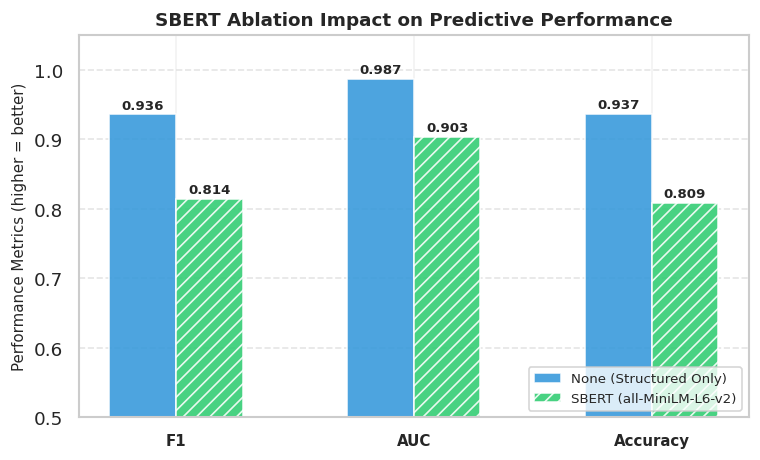

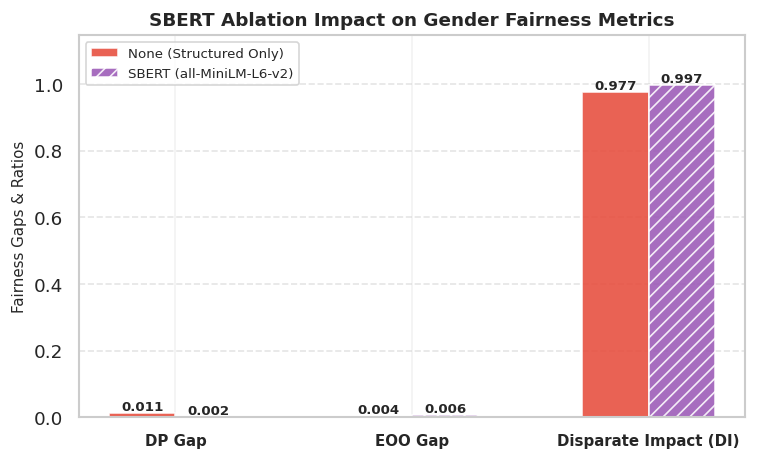


 Interpretation:
  F1 change with SBERT      : -0.1218 (decreased)
  DP Gap Gender change      : -0.0096 (fairer)
  DI Gender change          : +0.0195 (fairer)

  → SBERT DOES NOT improve predictive performance
  → SBERT IMPROVES gender fairness (DP Gap)


In [ ]:
# ====================================================================
# SBERT Ablation Study
# RQ3: Can Sentence-BERT improve both fairness and predictive accuracy?
# So sánh: No Text (Structured Only) vs SBERT Early Fusion
# Classifier đại diện: RF (thường best performer)
# ====================================================================
print("=" * 60)
print("  SBERT Ablation Study")
print("  No Text vs SBERT (Early Fusion, Random Forest)")
print("=" * 60)

ablation_records = []

# ===== Condition 1: No Text — Structured Only (Baseline) =====
# Lấy từ rf_models đã có, key = Setting A blind label
baseline_key = 'A: Competency Only | blind'
_, _, y_te_b, y_pred_b, y_prob_b = rf_models[baseline_key]

di_g_b = compute_di(y_pred_b, gender_te)
di_e_b = compute_di(y_pred_b, ethnicity_te)

ablation_records.append({
    'Text Representation': 'None (Structured Only)',
    'Fusion':   'N/A',
    'F1':       round(f1_score(y_te_b, y_pred_b), 4),
    'AUC':      round(roc_auc_score(y_te_b, y_prob_b), 4),
    'Accuracy': round(accuracy_score(y_te_b, y_pred_b), 4),
    'DP_Gap_Gender':    round(rf_fairness_g[baseline_key]['DP Gap'].mean(), 4),
    'EOO_Gap_Gender':   round(rf_fairness_g[baseline_key]['EOO Gap'].mean(), 4),
    'DI_Gender':        di_g_b,
    'DP_Gap_Ethnicity': round(rf_fairness_e[baseline_key]['DP Gap'].mean(), 4),
    'DI_Ethnicity':     di_e_b,
})

# ===== Condition 2: SBERT Early Fusion (từ Cell 44) =====
_, y_pred_e, y_prob_e = early_models['RF']

di_g_e = compute_di(y_pred_e, gender_te)
di_e_e = compute_di(y_pred_e, ethnicity_te)

ablation_records.append({
    'Text Representation': 'SBERT (all-MiniLM-L6-v2)',
    'Fusion':   'Early Fusion',
    'F1':       early_results['RF']['F1'],
    'AUC':      early_results['RF']['ROC-AUC'],
    'Accuracy': early_results['RF']['Accuracy'],
    'DP_Gap_Gender':    round(early_fairness_g['RF']['DP Gap'].mean(), 4),
    'EOO_Gap_Gender':   round(early_fairness_g['RF']['EOO Gap'].mean(), 4),
    'DI_Gender':        di_g_e,
    'DP_Gap_Ethnicity': round(early_fairness_e['RF']['DP Gap'].mean(), 4),
    'DI_Ethnicity':     di_e_e,
})

ablation_df = (pd.DataFrame(ablation_records)
               .set_index('Text Representation')
               .round(4))

print("\n SBERT Ablation Results (Random Forest):")
display(ablation_df)

# ===== Lưu kết quả =====─
ablation_df.to_csv('ablation_sbert.csv')
print("Saved: ablation_sbert.csv")

print('\n')
# ===== Visualization =====
print("========Impact on Performance & Fairness=======")
print("          Random Forest | Early Fusion vs Structured Only")
# ===== VISUALIZATION 1: SBERT Ablation - Predictive Performance (Separated & Smaller) =====
metric_cols_1 = ['F1', 'AUC', 'Accuracy']
ylabel_1 = 'Performance Metrics (higher = better)'

fig, ax = plt.subplots(figsize=(6.5, 4.0))

x = np.arange(len(metric_cols_1))
w = 0.28
reps = ablation_df.index.tolist()
offsets = [-w/2, w/2]
colors_perf = ['#3498DB', '#2ecc71'] # Định màu sắc phân biệt rõ ràng cho 2 nền tảng cấu trúc

for rep, offset, color, hatch in zip(reps, offsets, colors_perf, ['', '///']):
    if rep in ablation_df.index:
        vals = [ablation_df.loc[rep, m] for m in metric_cols_1]
        bars = ax.bar(x + offset, vals, w, label=rep, color=color, alpha=0.88, edgecolor='white', hatch=hatch)

        # Thêm thông số dữ liệu cụ thể dạng nằm ngang (rotation=0) siêu gọn gàng
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols_1, fontsize=9, fontweight='bold')
ax.set_ylabel(ylabel_1, fontsize=9)
ax.set_title('SBERT Ablation Impact on Predictive Performance', fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('sbert_ablation_performance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n')
# ===== VISUALIZATION 2: SBERT Ablation - Fairness Evaluation (Separated & Smaller) =====
metric_cols_2 = ['DP_Gap_Gender', 'EOO_Gap_Gender', 'DI_Gender']
ylabel_2 = 'Fairness Gaps & Ratios'

fig, ax = plt.subplots(figsize=(6.5, 4.0))

colors_fair = ['#e74c3c', '#9b59b6'] # Phân tầng màu cảnh báo trực quan cho Fairness

for rep, offset, color, hatch in zip(reps, offsets, colors_fair, ['', '///']):
    if rep in ablation_df.index:
        vals = [ablation_df.loc[rep, m] for m in metric_cols_2]
        bars = ax.bar(x + offset, vals, w, label=rep, color=color, alpha=0.88, edgecolor='white', hatch=hatch)

        # Thêm chỉ số giá trị số học chi tiết lên đầu cột
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['DP Gap', 'EOO Gap', 'Disparate Impact (DI)'], fontsize=9, fontweight='bold')
ax.set_ylabel(ylabel_2, fontsize=9)
ax.set_title('SBERT Ablation Impact on Gender Fairness Metrics', fontsize=11, fontweight='bold')

# Co giãn động ylim dựa trên giá trị lớn nhất của bộ chỉ số nhằm chống tràn chữ viết dữ liệu
max_val = max([ablation_df.loc[rep, m] for rep in reps for m in metric_cols_2])
ax.set_ylim(0, max_val * 1.15)

ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('sbert_ablation_fairness.png', bbox_inches='tight', dpi=150)
plt.show()


# ===== Interpretation tự động =====
f1_diff = (ablation_df.loc['SBERT (all-MiniLM-L6-v2)', 'F1'] -
           ablation_df.loc['None (Structured Only)', 'F1'])
dp_diff = (ablation_df.loc['SBERT (all-MiniLM-L6-v2)', 'DP_Gap_Gender'] -
           ablation_df.loc['None (Structured Only)', 'DP_Gap_Gender'])
di_diff = (ablation_df.loc['SBERT (all-MiniLM-L6-v2)', 'DI_Gender'] -
           ablation_df.loc['None (Structured Only)', 'DI_Gender'])

print("\n Interpretation:")
print(f"  F1 change with SBERT      : {f1_diff:+.4f} "
      f"({'improved' if f1_diff > 0 else 'decreased'})")
print(f"  DP Gap Gender change      : {dp_diff:+.4f} "
      f"({'fairer' if dp_diff < 0 else 'less fair'})")
print(f"  DI Gender change          : {di_diff:+.4f} "
      f"({'fairer' if di_diff > 0 else 'less fair'})")
print(f"\n  → SBERT {'IMPROVES' if f1_diff > 0 else 'DOES NOT improve'} "
      f"predictive performance")
print(f"  → SBERT {'IMPROVES' if dp_diff < 0 else 'DOES NOT improve'} "
      f"gender fairness (DP Gap)")

### RQ4: Bias Mitigation

  Bias Mitigation Experiments
  Proposal Section 12: 3 Lightweight Techniques

[1/3] Technique 1: Sensitive Attribute Removal
      → Reusing Setting A baseline (no demographic cols in features)
Done

[2/3] Technique 2: Attribute Masking (bio_anonymized via SBERT)
      → Reusing Early Fusion RF from Cell 44
Done

[3/3] Technique 3: Sample Reweighting...
Done

 Bias Mitigation Comparison (Random Forest):


,F1,AUC,Accuracy,DP_Gap_Gender,EOO_Gap_Gender,DI_Gender,DP_Gap_Ethnicity,DI_Ethnicity
Technique,,,,,,,,
T1: Sensitive Attr. Removal\n(Structured Only),0.9359,0.9866,0.9367,0.0115,0.0043,0.9770,0.0218,0.9572
T2: Attribute Masking\n(SBERT + bio_anonymized),0.8141,0.9033,0.8088,0.0019,0.0056,0.9965,0.0472,0.9155
T3: Sample Reweighting\n(Early Fusion + weights),0.8177,0.9044,0.8127,0.0010,0.0192,0.9981,0.0341,0.9380


Saved: bias_mitigation_results.csv


======= Bias Mitigation Techniques: Performance vs Fairness======
        Random Forest | 3 Techniques from Proposal Section 12


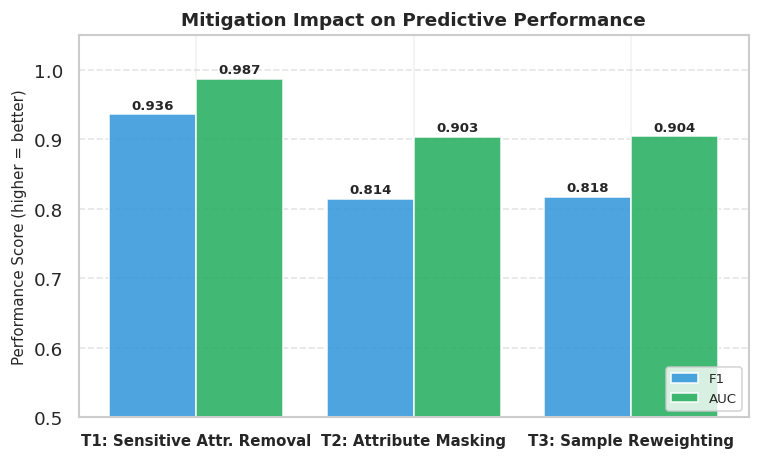

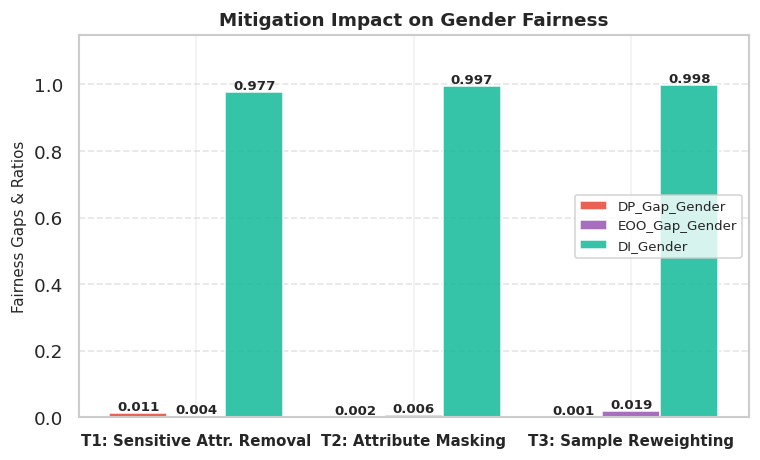


 Interpretation:
  Fairest technique (lowest DP Gap Gender): T3 (0.0010)
  Best performance (highest F1):            T1 (0.9359)

  T1 → T2 DP Gap change: -0.0096 (fairer)
  T1 → T3 DP Gap change: -0.0105 (fairer)

  Note: Lower DP Gap may come at cost of F1 — this is the fairness-accuracy trade-off 


In [ ]:
# =====================================================================
# Bias Mitigation Experiments
# RQ4: How do lightweight bias mitigation techniques affect performance?
#
# Proposal Section 12:
#   Technique 1: Sensitive Attribute Removal  → Setting A (đã có)
#   Technique 2: Attribute Masking            → dùng bio_anonymized
#   Technique 3: Sample Reweighting           → inverse freq weighting
#
# Classifier đại diện: RF, Early Fusion
# =====================================================================

print("=" * 60)
print("  Bias Mitigation Experiments")
print("  Proposal Section 12: 3 Lightweight Techniques")
print("=" * 60)

from collections import Counter

# ===== Helper: sample reweighting =====
def compute_sample_weights(y_train, sensitive_train):
    """
    Inverse frequency weighting per Proposal Section 12.3.
    Trả về sample_weight array để dùng trong clf.fit().
    """
    groups = list(zip(y_train.tolist(), sensitive_train.tolist()))
    counts = Counter(groups)
    total  = len(y_train)
    w = np.array([total / (len(counts) * counts[(y, s)])
                  for y, s in groups])
    return w / w.mean()   # normalize về mean = 1

mitigation_records = []

# ====================================================================
# Technique 1: Sensitive Attribute Removal
# → Đây chính là Setting A (không có gender/ethnicity trong features)
# → Kết quả đã có trong rf_models — tái sử dụng trực tiếp
# ====================================================================
print("\n[1/3] Technique 1: Sensitive Attribute Removal")
print("      → Reusing Setting A baseline (no demographic cols in features)")

baseline_key = 'A: Competency Only | blind'
_, _, y_te_b, y_pred_b, y_prob_b = rf_models[baseline_key]

mitigation_records.append({
    'Technique':        'T1: Sensitive Attr. Removal\n(Structured Only)',
    'F1':               round(f1_score(y_te_b, y_pred_b), 4),
    'AUC':              round(roc_auc_score(y_te_b, y_prob_b), 4),
    'Accuracy':         round(accuracy_score(y_te_b, y_pred_b), 4),
    'DP_Gap_Gender':    round(rf_fairness_g[baseline_key]['DP Gap'].mean(), 4),
    'EOO_Gap_Gender':   round(rf_fairness_g[baseline_key]['EOO Gap'].mean(), 4),
    'DI_Gender':        compute_di(y_pred_b, gender_te),
    'DP_Gap_Ethnicity': round(rf_fairness_e[baseline_key]['DP Gap'].mean(), 4),
    'DI_Ethnicity':     compute_di(y_pred_b, ethnicity_te),
})
print("Done")

# ====================================================================
# Technique 2: Attribute Masking
# → SBERT đã encode bio_anonymized (gender pronouns đã bị mask)
# → Early Fusion RF từ Cell 44 chính là kết quả của technique này
# → Tái sử dụng early_models['RF'] trực tiếp
# ====================================================================
print("\n[2/3] Technique 2: Attribute Masking (bio_anonymized via SBERT)")
print("      → Reusing Early Fusion RF from Cell 44")

_, y_pred_e, y_prob_e = early_models['RF']

mitigation_records.append({
    'Technique':        'T2: Attribute Masking\n(SBERT + bio_anonymized)',
    'F1':               early_results['RF']['F1'],
    'AUC':              early_results['RF']['ROC-AUC'],
    'Accuracy':         early_results['RF']['Accuracy'],
    'DP_Gap_Gender':    round(early_fairness_g['RF']['DP Gap'].mean(), 4),
    'EOO_Gap_Gender':   round(early_fairness_g['RF']['EOO Gap'].mean(), 4),
    'DI_Gender':        compute_di(y_pred_e, gender_te),
    'DP_Gap_Ethnicity': round(early_fairness_e['RF']['DP Gap'].mean(), 4),
    'DI_Ethnicity':     compute_di(y_pred_e, ethnicity_te),
})
print("Done")

# ====================================================================
# Technique 3: Sample Reweighting
# → Train RF trên Early Fusion features với sample weights
# → Weights = inverse frequency của (label, gender) groups
# ====================================================================
print("\n[3/3] Technique 3: Sample Reweighting...")

# Lấy gender của train set
gender_tr_arr = df[df['split'] == 'train']['gender'].values

# Compute weights dựa trên (label, gender) distribution
sample_weights = compute_sample_weights(y_tr_fusion, gender_tr_arr)

# Early Fusion features (đã có từ Cell 44)
X_early_tr_rw = np.concatenate([X_text_tr, X_struct_tr], axis=1)
X_early_te_rw = np.concatenate([X_text_te, X_struct_te], axis=1)

# Train RF với sample_weight
rf_weighted = RandomForestClassifier(
    **best_rf_params,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_weighted.fit(X_early_tr_rw, y_tr_fusion, sample_weight=sample_weights)

y_pred_w = rf_weighted.predict(X_early_te_rw)
y_prob_w = rf_weighted.predict_proba(X_early_te_rw)[:, 1]

fair_w_g = compute_group_metrics(y_te_fusion, y_pred_w, gender_te, GENDER_LABELS)
fair_w_e = compute_group_metrics(y_te_fusion, y_pred_w, ethnicity_te, ETH_LABELS)

mitigation_records.append({
    'Technique':        'T3: Sample Reweighting\n(Early Fusion + weights)',
    'F1':               round(f1_score(y_te_fusion, y_pred_w), 4),
    'AUC':              round(roc_auc_score(y_te_fusion, y_prob_w), 4),
    'Accuracy':         round(accuracy_score(y_te_fusion, y_pred_w), 4),
    'DP_Gap_Gender':    round(fair_w_g['DP Gap'].mean(), 4),
    'EOO_Gap_Gender':   round(fair_w_g['EOO Gap'].mean(), 4),
    'DI_Gender':        compute_di(y_pred_w, gender_te),
    'DP_Gap_Ethnicity': round(fair_w_e['DP Gap'].mean(), 4),
    'DI_Ethnicity':     compute_di(y_pred_w, ethnicity_te),
})
print("Done")

# ===== Build results table =====
mitigation_df = (pd.DataFrame(mitigation_records)
                 .set_index('Technique')
                 .round(4))

print("\n Bias Mitigation Comparison (Random Forest):")
display(mitigation_df)

# ===== Lưu kết quả =====
mitigation_df.to_csv('bias_mitigation_results.csv')
print("Saved: bias_mitigation_results.csv")

# ===== Visualization =====
print('\n')
print('======= Bias Mitigation Techniques: Performance vs Fairness======')
print('        Random Forest | 3 Techniques from Proposal Section 12')
# ===== VISUALIZATION 1: Bias Mitigation - Predictive Performance (Separated & Smaller) =====
technique_labels = [t.split('\n')[0] for t in mitigation_df.index]
metrics_perf = ['F1', 'AUC']
colors_perf = ['#3498DB', '#27AE60']

fig, ax = plt.subplots(figsize=(6.5, 4.0))
x = np.arange(len(technique_labels))
w = 0.8 / len(metrics_perf)

for i, (metric, color) in enumerate(zip(metrics_perf, colors_perf)):
    vals = mitigation_df[metric].values
    offset = (i - len(metrics_perf)/2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=metric, color=color, alpha=0.88, edgecolor='white')

    # Hiển thị số liệu nằm ngang (rotation=0) gọn gàng
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(technique_labels, fontsize=9, fontweight='bold')
ax.set_ylabel('Performance Score (higher = better)', fontsize=9)
ax.set_title('Mitigation Impact on Predictive Performance', fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('mitigation_performance_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n')
# ===== VISUALIZATION 2: Bias Mitigation - Fairness Comparison (Separated & Smaller) =====
metrics_fair = ['DP_Gap_Gender', 'EOO_Gap_Gender', 'DI_Gender']
colors_fair = ['#E74C3C', '#9B59B6', '#1ABC9C']

fig, ax = plt.subplots(figsize=(6.5, 4.0))
w = 0.8 / len(metrics_fair)

for i, (metric, color) in enumerate(zip(metrics_fair, colors_fair)):
    vals = mitigation_df[metric].values
    offset = (i - len(metrics_fair)/2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=metric, color=color, alpha=0.88, edgecolor='white')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(technique_labels, fontsize=9, fontweight='bold')
ax.set_ylabel('Fairness Gaps & Ratios', fontsize=9)
ax.set_title('Mitigation Impact on Gender Fairness', fontsize=11, fontweight='bold')

max_fair_val = max(mitigation_df[metrics_fair].max())
ax.set_ylim(0, max_fair_val * 1.15)
ax.legend(fontsize=8, loc='center right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('mitigation_fairness_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
# ===== Interpretation tự động =====
print("\n Interpretation:")
t1_dp = mitigation_df.loc['T1: Sensitive Attr. Removal\n(Structured Only)', 'DP_Gap_Gender']
t2_dp = mitigation_df.loc['T2: Attribute Masking\n(SBERT + bio_anonymized)', 'DP_Gap_Gender']
t3_dp = mitigation_df.loc['T3: Sample Reweighting\n(Early Fusion + weights)', 'DP_Gap_Gender']

t1_f1 = mitigation_df.loc['T1: Sensitive Attr. Removal\n(Structured Only)', 'F1']
t2_f1 = mitigation_df.loc['T2: Attribute Masking\n(SBERT + bio_anonymized)', 'F1']
t3_f1 = mitigation_df.loc['T3: Sample Reweighting\n(Early Fusion + weights)', 'F1']

best_fair_tech = min(
    [('T1', t1_dp), ('T2', t2_dp), ('T3', t3_dp)],
    key=lambda x: x[1]
)
best_perf_tech = max(
    [('T1', t1_f1), ('T2', t2_f1), ('T3', t3_f1)],
    key=lambda x: x[1]
)

print(f"  Fairest technique (lowest DP Gap Gender): "
      f"{best_fair_tech[0]} ({best_fair_tech[1]:.4f})")
print(f"  Best performance (highest F1):            "
      f"{best_perf_tech[0]} ({best_perf_tech[1]:.4f})")
print(f"\n  T1 → T2 DP Gap change: {t2_dp - t1_dp:+.4f} "
      f"({'fairer' if t2_dp < t1_dp else 'less fair'})")
print(f"  T1 → T3 DP Gap change: {t3_dp - t1_dp:+.4f} "
      f"({'fairer' if t3_dp < t1_dp else 'less fair'})")
print(f"\n  Note: Lower DP Gap may come at cost of F1 — this is the "
      f"fairness-accuracy trade-off ")

 ### RQ5: Accuracy-Fairness Trade-off

  RQ5 — Accuracy vs. Fairness Trade-off


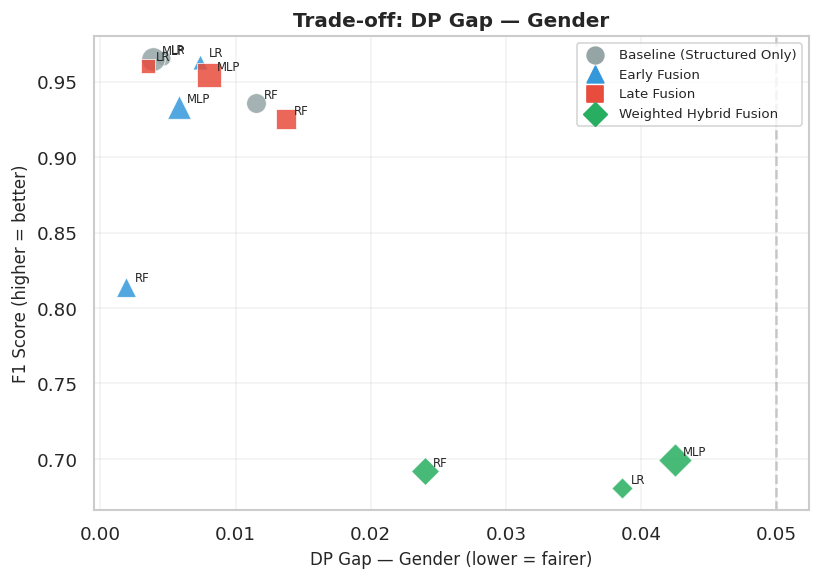

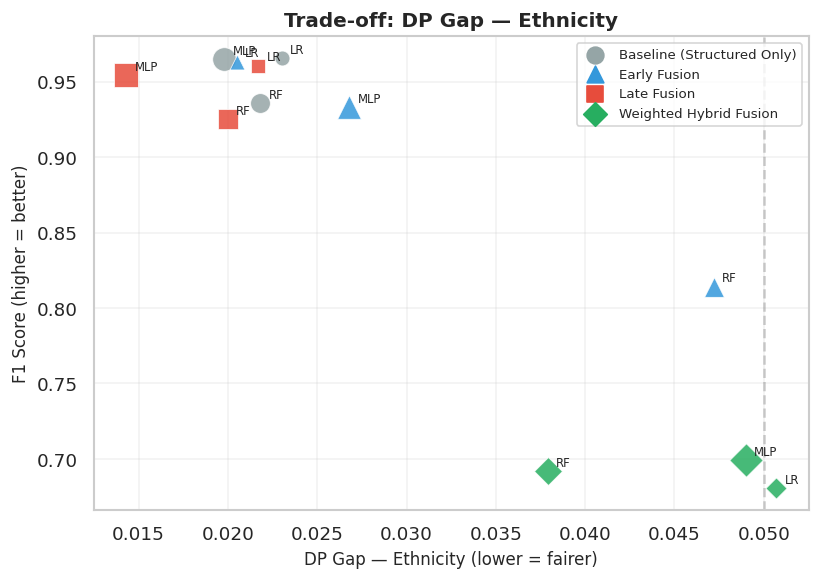


 RQ5 Interpretation:
  Fusion strategies closer to top-left = better accuracy AND fairer
  Best accuracy: Baseline (Structured Only) - LR
  Fairest (Gender DP): Early Fusion - RF


In [ ]:
# ====================================================================
# Accuracy vs Fairness Trade-off (RQ5)
#
# RQ5: What trade-offs exist between fairness and accuracy in
#      multimodal fusion system ?
# =====================================================================

print("=" * 60)
print("  RQ5 — Accuracy vs. Fairness Trade-off")
print("=" * 60)

# ===== VISUALIZATION 1: Accuracy-Fairness Trade-off for Gender (Original Scaling) =====
import matplotlib.pyplot as plt

pal_fusion_scatter = {
    'Baseline (Structured Only)': ('o', '#95A5A6'),
    'Early Fusion':               ('^', '#3498DB'),
    'Late Fusion':                ('s', '#E74C3C'),
    'Weighted Hybrid Fusion':     ('D', '#27AE60'), # Đồng bộ chuỗi tên trong fusion_master_df
}
clf_sizes = {'LR': 80, 'RF': 140, 'MLP': 200}

fig, ax = plt.subplots(figsize=(7, 5))

fair_col_1 = 'DP_Gap_Gender'
fair_label_1 = 'DP Gap — Gender'

for strat, (marker, color) in pal_fusion_scatter.items():
    sub = fusion_master_df[fusion_master_df['Fusion Strategy'] == strat]
    for _, row in sub.iterrows():
        ax.scatter(row[fair_col_1], row['F1'],
                   marker=marker, color=color, s=clf_sizes[row['Classifier']],
                   alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.annotate(row['Classifier'], (row[fair_col_1], row['F1']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

# Khôi phục toàn bộ nhãn và cấu hình trục tự động gốc
ax.set_xlabel(f'{fair_label_1} (lower = fairer)', fontsize=10)
ax.set_ylabel('F1 Score (higher = better)', fontsize=10)
ax.set_title(f'Trade-off: {fair_label_1}', fontweight='bold')

ax.axvline(0.05, color='gray', linestyle='--', alpha=0.4, label='Gap=0.05 threshold')

# Tạo Chú thích (Legend) đại diện theo chiến lược
handles = [plt.scatter([], [], marker=m, color=c, s=100, label=s) for s, (m, c) in pal_fusion_scatter.items()]
ax.legend(handles=handles, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('tradeoff_gender.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n')
# ===== VISUALIZATION 2: Accuracy-Fairness Trade-off for Ethnicity (Original Scaling) =====
fig, ax = plt.subplots(figsize=(7, 5))

fair_col_2 = 'DP_Gap_Ethnicity'
fair_label_2 = 'DP Gap — Ethnicity'

for strat, (marker, color) in pal_fusion_scatter.items():
    sub = fusion_master_df[fusion_master_df['Fusion Strategy'] == strat]
    for _, row in sub.iterrows():
        ax.scatter(row[fair_col_2], row['F1'],
                   marker=marker, color=color, s=clf_sizes[row['Classifier']],
                   alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.annotate(row['Classifier'], (row[fair_col_2], row['F1']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

# Khôi phục toàn bộ nhãn và cấu hình trục tự động gốc
ax.set_xlabel(f'{fair_label_2} (lower = fairer)', fontsize=10)
ax.set_ylabel('F1 Score (higher = better)', fontsize=10)
ax.set_title(f'Trade-off: {fair_label_2}', fontweight='bold')

ax.axvline(0.05, color='gray', linestyle='--', alpha=0.4, label='Gap=0.05 threshold')

handles = [plt.scatter([], [], marker=m, color=c, s=100, label=s) for s, (m, c) in pal_fusion_scatter.items()]
ax.legend(handles=handles, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('tradeoff_ethnicity.png', bbox_inches='tight', dpi=150)
plt.show()


print("\n RQ5 Interpretation:")
print("  Fusion strategies closer to top-left = better accuracy AND fairer")
print(f"  Best accuracy: {fusion_master_df.loc[fusion_master_df['F1'].idxmax(), 'Fusion Strategy']} - "
      f"{fusion_master_df.loc[fusion_master_df['F1'].idxmax(), 'Classifier']}")
print(f"  Fairest (Gender DP): "
      f"{fusion_master_df.loc[fusion_master_df['DP_Gap_Gender'].idxmin(), 'Fusion Strategy']} - "
      f"{fusion_master_df.loc[fusion_master_df['DP_Gap_Gender'].idxmin(), 'Classifier']}")

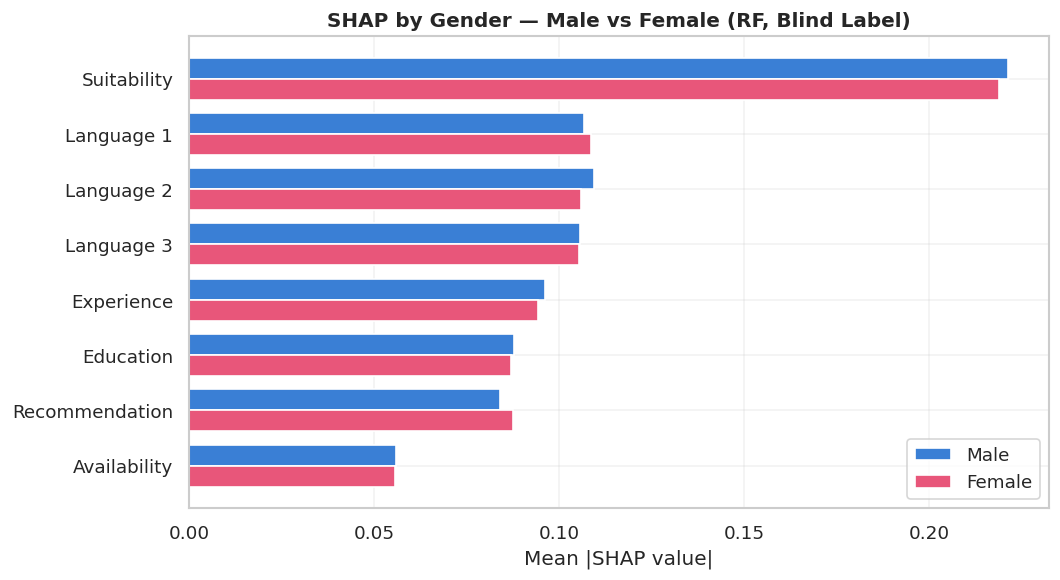

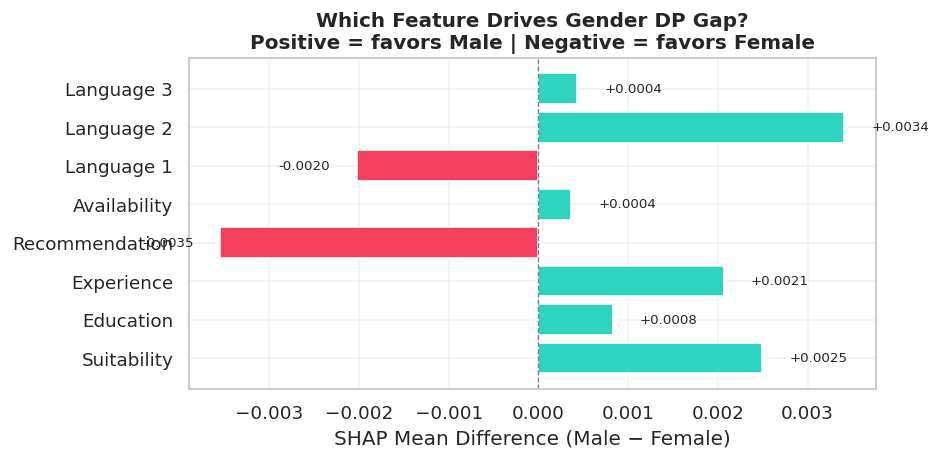

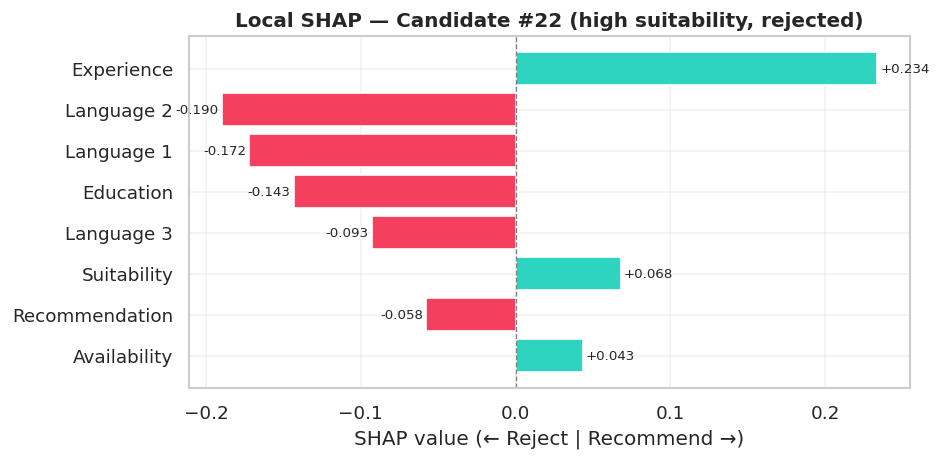

Candidate #22: predicted=Reject

Feature contribution to Gender DP Gap:
  Recommendation        : -0.0035  (favors Female)
  Language 2            : +0.0034  (favors Male)
  Suitability           : +0.0025  (favors Male)
  Experience            : +0.0021  (favors Male)
  Language 1            : -0.0020  (favors Female)
  Education             : +0.0008  (favors Male)
  Language 3            : +0.0004  (favors Male)
  Availability          : +0.0004  (favors Male)

Section 2 done — 3 plots saved


In [ ]:
# ════════════════════════════════════════════════════════════════════
# XAI — SHAP Per-Group Fairness (matplotlib thuần)
# sv đã fix shape ở Section 1
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

mask_male   = (gender_te == 0)
mask_female = (gender_te == 1)

mean_male   = np.abs(sv[mask_male]).mean(axis=0)
mean_female = np.abs(sv[mask_female]).mean(axis=0)

# ── Plot 3: Grouped bar — Male vs Female (1 chart, dễ so sánh) ──────
order   = np.argsort(mean_male + mean_female)
names_s = [COMP_NAMES[i] for i in order]
male_s   = mean_male[order]
female_s = mean_female[order]

y = np.arange(len(names_s)); h = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + h/2, male_s,   h, label='Male',   color='#3A7FD5')
ax.barh(y - h/2, female_s, h, label='Female', color='#E8567A')
ax.set_yticks(y); ax.set_yticklabels(names_s)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP by Gender — Male vs Female (RF, Blind Label)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('shap_gender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: SHAP Mean Difference — feature nào drive gap ────────────
shap_diff  = (mean_male - mean_female).flatten().tolist()
feat_names = list(COMP_NAMES)
colors = ['#2dd4bf' if d > 0 else '#f43f5e' for d in shap_diff]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feat_names, shap_diff, color=colors)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('SHAP Mean Difference (Male − Female)')
ax.set_title('Which Feature Drives Gender DP Gap?\n'
             'Positive = favors Male | Negative = favors Female', fontweight='bold')
for bar, val in zip(bars, shap_diff):
    ax.text(val + (0.0003 if val >= 0 else -0.0003),
            bar.get_y() + bar.get_height()/2, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('shap_dp_gap_source.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 5: Local explanation — 1 candidate (manual bar, không waterfall) ──
rf_obj, _, y_te_c, y_pred_c, _ = rf_models['A: Competency Only | blind']
high_suit_rej = np.where((X_te_A_raw[:, 0] >= 0.75) & (y_pred_c == 0))[0]

if len(high_suit_rej) > 0:
    idx = high_suit_rej[0]
    single = sv[idx]                         # shape (8,) — đã đúng
    order2 = np.argsort(np.abs(single))
    names2 = [COMP_NAMES[i] for i in order2]
    vals2  = single[order2]
    colors2 = ['#2dd4bf' if v > 0 else '#f43f5e' for v in vals2]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(names2, vals2, color=colors2)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel('SHAP value (← Reject | Recommend →)')
    ax.set_title(f'Local SHAP — Candidate #{idx} (high suitability, rejected)',
                 fontweight='bold')
    for bar, v in zip(bars, vals2):
        ax.text(v + (0.002 if v >= 0 else -0.002),
                bar.get_y() + bar.get_height()/2, f'{v:+.3f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    plt.tight_layout()
    plt.savefig('shap_waterfall_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Candidate #{idx}: predicted={'Recommend' if y_pred_c[idx] else 'Reject'}")
else:
    print("No high-suitability rejected candidate found.")

print("\nFeature contribution to Gender DP Gap:")
for feat, diff in sorted(zip(feat_names, shap_diff), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:22s}: {diff:+.4f}  ({'favors Male' if diff > 0 else 'favors Female'})")

print("\nSection 2 done — 3 plots saved")


  SECTION 3: SHAP by ETHNICITY (Group 1, 2, 3)


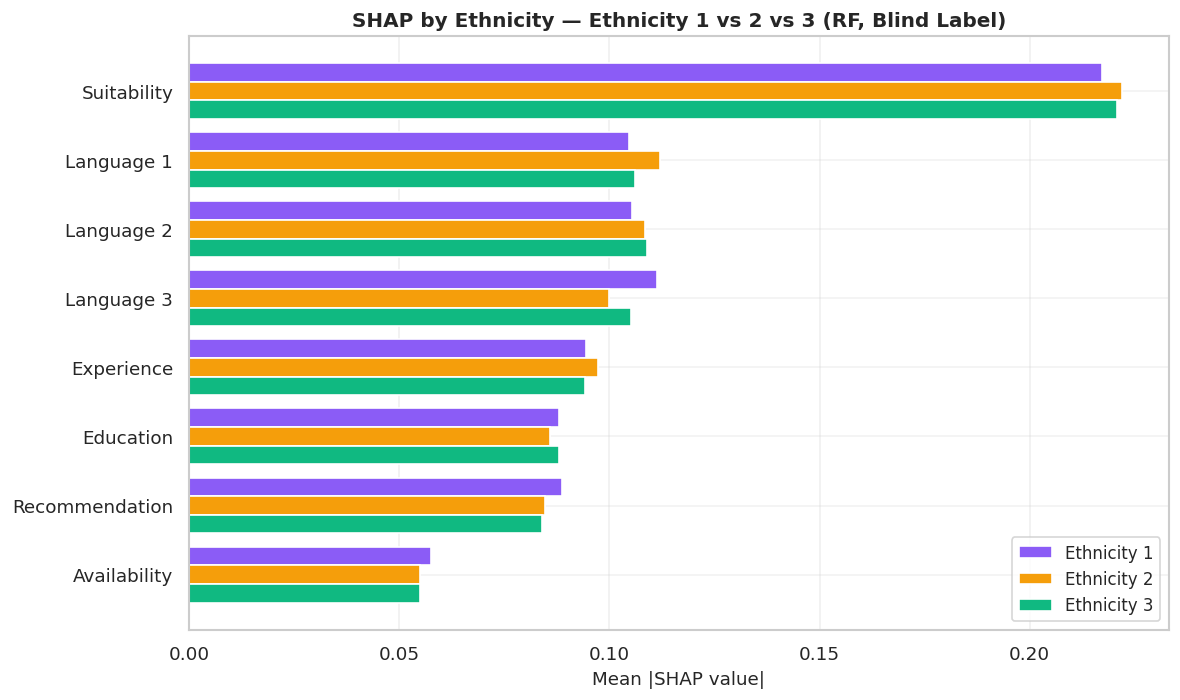

✓ Ethnicity comparison plot saved


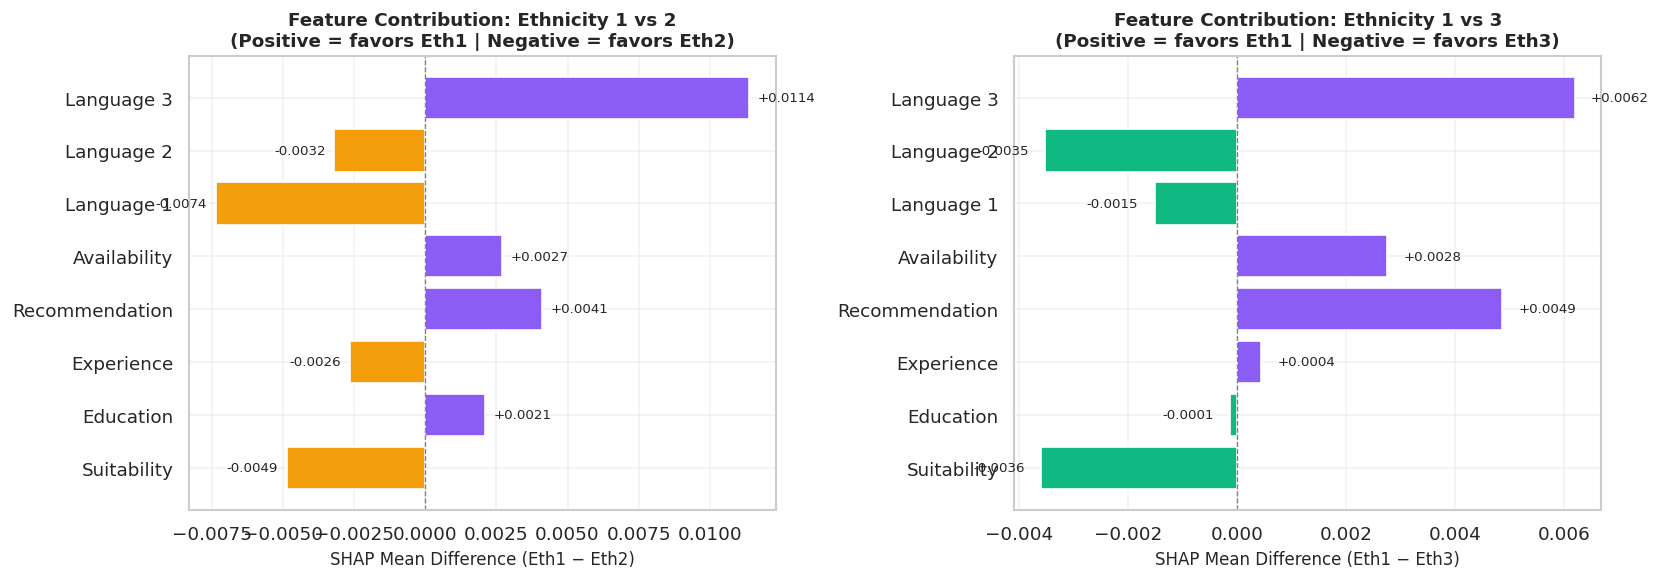

✓ Ethnicity gap analysis plots saved


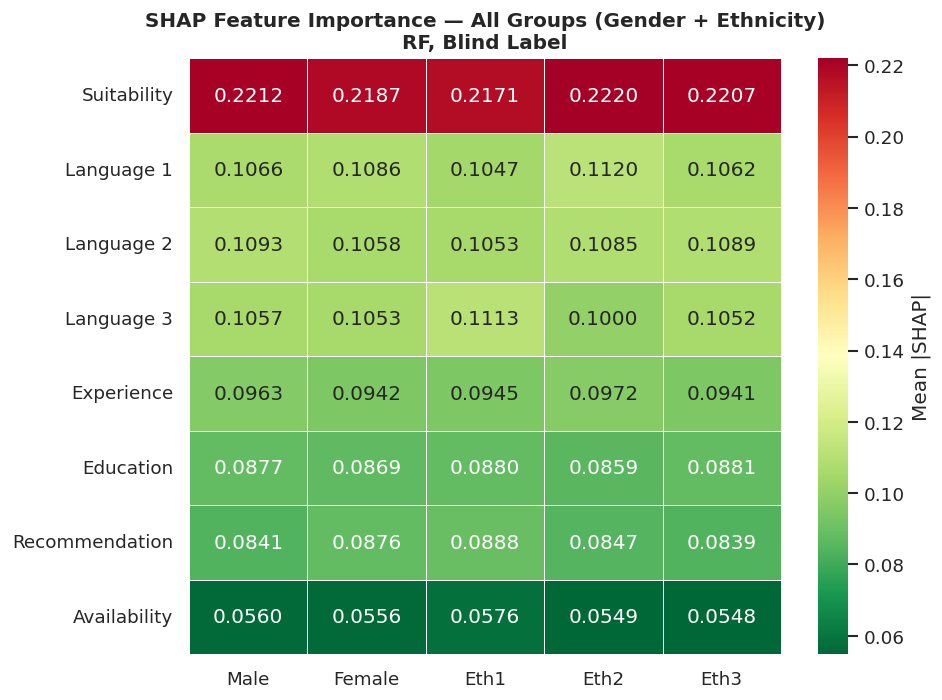

✓ All-groups heatmap saved

📋 SUMMARY: Mean |SHAP| by Feature & Group
       Feature     Male   Female     Eth1     Eth2     Eth3
   Suitability 0.221177 0.218679 0.217125 0.221993 0.220722
    Language 2 0.109261 0.105849 0.105333 0.108540 0.108858
    Language 1 0.106603 0.108626 0.104652 0.112017 0.106166
    Language 3 0.105704 0.105271 0.111343 0.099951 0.105158
    Experience 0.096270 0.094205 0.094524 0.097172 0.094087
     Education 0.087720 0.086887 0.087955 0.085869 0.088090
Recommendation 0.084067 0.087614 0.088810 0.084702 0.083949
  Availability 0.055965 0.055598 0.057604 0.054911 0.054848

✓ Summary saved to shap_group_summary.csv

⚠️  FAIRNESS INSIGHT: Features driving demographic gaps

Gender Disparity (High SHAP diff → strong gender proxy):
  ❌ Recommendation        : |diff| = 0.0035
  ❌ Language 2            : |diff| = 0.0034
  ❌ Suitability           : |diff| = 0.0025
  ❌ Experience            : |diff| = 0.0021
  ❌ Language 1            : |diff| = 0.0020

Ethnicity D

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 📊 SECTION 3: ETHNICITY-BASED SHAP ANALYSIS
# ════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("  SECTION 3: SHAP by ETHNICITY (Group 1, 2, 3)")
print("=" * 70)

# ── Plot 6: Grouped bar — Ethnicity 1 vs 2 vs 3 ──────────────────────
ETH_NAMES = {0: 'Ethnicity 1', 1: 'Ethnicity 2', 2: 'Ethnicity 3'}

mask_eth1 = (ethnicity_te == 0)
mask_eth2 = (ethnicity_te == 1)
mask_eth3 = (ethnicity_te == 2)

mean_eth1 = np.abs(sv[mask_eth1]).mean(axis=0)
mean_eth2 = np.abs(sv[mask_eth2]).mean(axis=0)
mean_eth3 = np.abs(sv[mask_eth3]).mean(axis=0)

# Sort by total importance
order_eth = np.argsort(mean_eth1 + mean_eth2 + mean_eth3)
names_eth = [COMP_NAMES[i] for i in order_eth]
eth1_s = mean_eth1[order_eth]
eth2_s = mean_eth2[order_eth]
eth3_s = mean_eth3[order_eth]

y = np.arange(len(names_eth))
h = 0.27

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + h,     eth1_s, h, label='Ethnicity 1', color='#8B5CF6')
ax.barh(y,         eth2_s, h, label='Ethnicity 2', color='#F59E0B')
ax.barh(y - h,     eth3_s, h, label='Ethnicity 3', color='#10B981')

ax.set_yticks(y)
ax.set_yticklabels(names_eth)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('SHAP by Ethnicity — Ethnicity 1 vs 2 vs 3 (RF, Blind Label)',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_ethnicity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Ethnicity comparison plot saved")

# ── Plot 7: SHAP Mean Difference — Ethnicity (1 vs 2) ─────────────────
shap_diff_eth12 = (mean_eth1 - mean_eth2).flatten().tolist()
shap_diff_eth13 = (mean_eth1 - mean_eth3).flatten().tolist()

feat_names = list(COMP_NAMES)
colors_12 = ['#8B5CF6' if d > 0 else '#F59E0B' for d in shap_diff_eth12]
colors_13 = ['#8B5CF6' if d > 0 else '#10B981' for d in shap_diff_eth13]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ethnicity 1 vs 2
bars1 = ax1.barh(feat_names, shap_diff_eth12, color=colors_12)
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_xlabel('SHAP Mean Difference (Eth1 − Eth2)', fontsize=10)
ax1.set_title('Feature Contribution: Ethnicity 1 vs 2\n(Positive = favors Eth1 | Negative = favors Eth2)',
              fontweight='bold', fontsize=11)
for bar, val in zip(bars1, shap_diff_eth12):
    ax1.text(val + (0.0003 if val >= 0 else -0.0003),
            bar.get_y() + bar.get_height()/2, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# Ethnicity 1 vs 3
bars2 = ax2.barh(feat_names, shap_diff_eth13, color=colors_13)
ax2.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_xlabel('SHAP Mean Difference (Eth1 − Eth3)', fontsize=10)
ax2.set_title('Feature Contribution: Ethnicity 1 vs 3\n(Positive = favors Eth1 | Negative = favors Eth3)',
              fontweight='bold', fontsize=11)
for bar, val in zip(bars2, shap_diff_eth13):
    ax2.text(val + (0.0003 if val >= 0 else -0.0003),
            bar.get_y() + bar.get_height()/2, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('shap_ethnicity_gap_source.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Ethnicity gap analysis plots saved")

# ── Plot 8: Heatmap — All groups (Gender + Ethnicity) ─────────────────
import seaborn as sns

# Tạo matrix: features × groups
groups = {
    'Male': mean_male,
    'Female': mean_female,
    'Eth1': mean_eth1,
    'Eth2': mean_eth2,
    'Eth3': mean_eth3,
}

matrix_data = np.array([groups[g] for g in groups.keys()]).T
feat_order = np.argsort(matrix_data.mean(axis=1))[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix_data[feat_order],
            xticklabels=groups.keys(),
            yticklabels=[COMP_NAMES[i] for i in feat_order],
            cmap='RdYlGn_r', annot=True, fmt='.4f', cbar_kws={'label': 'Mean |SHAP|'},
            ax=ax, linewidths=0.5)
ax.set_title('SHAP Feature Importance — All Groups (Gender + Ethnicity)\nRF, Blind Label',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('shap_all_groups_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ All-groups heatmap saved")

# ── Summary Table: Mean SHAP by Group ────────────────────────────────
summary_shap = pd.DataFrame({
    'Feature': [COMP_NAMES[i] for i in range(len(COMP_NAMES))],
    'Male': mean_male,
    'Female': mean_female,
    'Eth1': mean_eth1,
    'Eth2': mean_eth2,
    'Eth3': mean_eth3,
})
summary_shap = summary_shap.sort_values('Male', ascending=False)

print("\n" + "=" * 80)
print("📋 SUMMARY: Mean |SHAP| by Feature & Group")
print("=" * 80)
print(summary_shap.to_string(index=False))
summary_shap.to_csv('shap_group_summary.csv', index=False)
print("\n✓ Summary saved to shap_group_summary.csv")

# ── Feature Fairness Score: Which features drive unfairness? ──────────
print("\n" + "=" * 80)
print("⚠️  FAIRNESS INSIGHT: Features driving demographic gaps")
print("=" * 80)

print("\nGender Disparity (High SHAP diff → strong gender proxy):")
gender_disparity = sorted(zip(COMP_NAMES, np.abs(shap_diff)), key=lambda x: x[1], reverse=True)
for feat, diff in gender_disparity[:5]:
    print(f"  ❌ {feat:22s}: |diff| = {diff:.4f}")

print("\nEthnicity Disparity (Eth1 vs Eth2):")
eth_disparity_12 = sorted(zip(COMP_NAMES, np.abs(shap_diff_eth12)), key=lambda x: x[1], reverse=True)
for feat, diff in eth_disparity_12[:5]:
    print(f"  ❌ {feat:22s}: |diff| = {diff:.4f}")

print("\nEthnicity Disparity (Eth1 vs Eth3):")
eth_disparity_13 = sorted(zip(COMP_NAMES, np.abs(shap_diff_eth13)), key=lambda x: x[1], reverse=True)
for feat, diff in eth_disparity_13[:5]:
    print(f"  ❌ {feat:22s}: |diff| = {diff:.4f}")

print("\n✓ Section 3 done — Group SHAP analysis complete")

In [ ]:
# ════════════════════════════════════════════════════════════════════
# GROUP SHAP — Bước 1: Tính SHAP values trên Early Fusion RF
#
# Model: Early Fusion RF (early_models['RF']) — fusion tốt nhất theo RQ1
# Input: X_early_te (4800, 392) = [SBERT 384 | structured 8]
# Phân tích theo nhóm: Gender (Male/Female) và Ethnicity (G1/G2/G3)
# ════════════════════════════════════════════════════════════════════

import shap
import numpy as np

print("=" * 60)
print("  GROUP SHAP — computing on Early Fusion RF")
print("=" * 60)

# ── Lấy model RF đã train ở Early Fusion ──────────────────────────────
rf_early = early_models['RF'][0]

# ── Subsample test để tính nhanh (TreeExplainer trên 392 features) ────
N_SHAP = 1500   # đủ để ổn định, chạy nhanh trên Colab
rng = np.random.RandomState(RANDOM_SEED)
idx = rng.choice(X_early_te.shape[0], size=min(N_SHAP, X_early_te.shape[0]),
                 replace=False)

X_shap     = X_early_te[idx]
gender_sh  = gender_te[idx]
eth_sh     = ethnicity_te[idx]

print(f"  Mẫu SHAP: {X_shap.shape[0]} rows × {X_shap.shape[1]} features")
print("  Đang tính TreeExplainer... (≈30–90s)")

explainer = shap.TreeExplainer(rf_early)
raw_sv = explainer.shap_values(X_shap)

# ── Chuẩn hóa output về shape (n_samples, n_features) cho class 1 ─────
# shap trả về nhiều format tùy version → xử lý an toàn
if isinstance(raw_sv, list):
    sv = np.array(raw_sv[1])            # class 1
elif raw_sv.ndim == 3:
    sv = raw_sv[:, :, 1]                # (n, feat, classes) → class 1
else:
    sv = raw_sv

print(f"  SHAP values shape: {sv.shape}")

# ── Tách 8 structured features (có tên) khỏi 384 SBERT ───────────────
N_TEXT = X_text_te.shape[1]             # = 384
sv_struct = sv[:, N_TEXT:]             # (n, 8) — phần competency
sv_text   = sv[:, :N_TEXT]            # (n, 384) — phần SBERT

COMP_NAMES = list(COMPETENCY)          # 8 tên feature có ý nghĩa
print(f"  Structured features: {COMP_NAMES}")
print("✓ Đã tính xong SHAP. Sang cell tiếp theo để vẽ.")

  GROUP SHAP — computing on Early Fusion RF
  Mẫu SHAP: 1500 rows × 392 features
  Đang tính TreeExplainer... (≈30–90s)
  SHAP values shape: (1500, 392)
  Structured features: ['suitability', 'educ_attainment', 'prev_experience', 'recommendation', 'availability', 'lang_prof_1', 'lang_prof_2', 'lang_prof_3']
✓ Đã tính xong SHAP. Sang cell tiếp theo để vẽ.


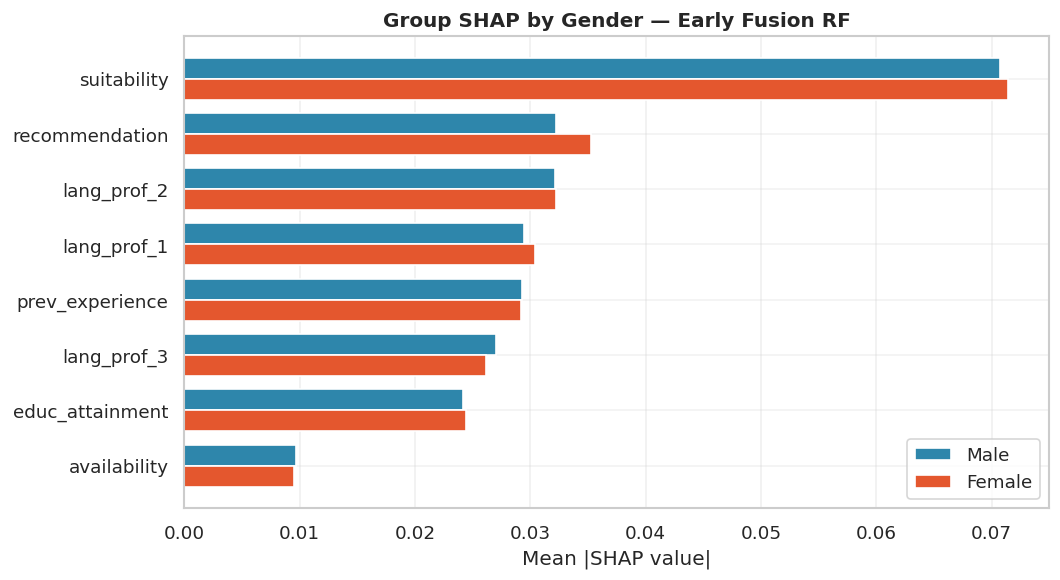

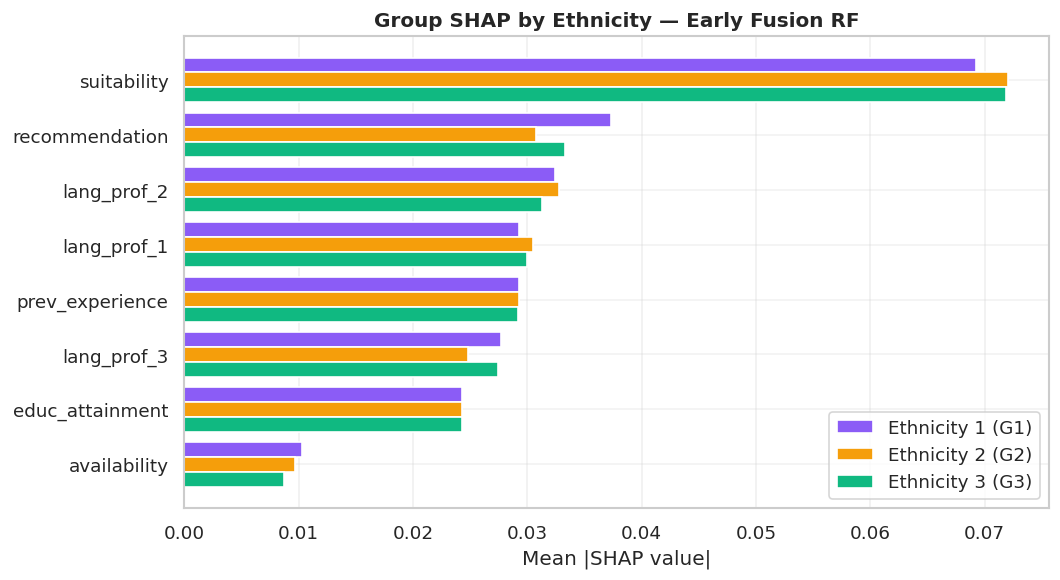


 Group SHAP — mean|SHAP| theo nhóm (8 structured features):


,Feature,Male,Female,Eth1,Eth2,Eth3
0,suitability,0.0707,0.0714,0.0693,0.0720,0.0719
3,recommendation,0.0322,0.0353,0.0374,0.0307,0.0333
6,lang_prof_2,0.0321,0.0322,0.0324,0.0328,0.0313
5,lang_prof_1,0.0294,0.0304,0.0292,0.0305,0.0300
2,prev_experience,0.0293,0.0291,0.0292,0.0293,0.0292
7,lang_prof_3,0.0270,0.0262,0.0277,0.0248,0.0274
1,educ_attainment,0.0241,0.0244,0.0243,0.0243,0.0243
4,availability,0.0096,0.0095,0.0103,0.0097,0.0087



 Trung bình |SHAP| — Text(SBERT): 0.0009 | Structured: 0.0321
✓ Đã lưu: shap_group_gender.png, shap_group_ethnicity.png, shap_group_summary.csv


In [ ]:
# ════════════════════════════════════════════════════════════════════
# GROUP SHAP — Bước 2: Vẽ theo nhóm Gender & Ethnicity
# ════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pandas as pd

# ── Helper: mean|SHAP| của 8 structured feature cho 1 nhóm ────────────
def group_mean_shap(sv_block, mask):
    return np.abs(sv_block[mask]).mean(axis=0)

# ────────────────────────────────────────────────────────────────────
# PLOT 1 — GENDER: Male vs Female
# ────────────────────────────────────────────────────────────────────
mean_male   = group_mean_shap(sv_struct, gender_sh == 0)
mean_female = group_mean_shap(sv_struct, gender_sh == 1)

order = np.argsort(mean_male + mean_female)      # sort theo tổng độ quan trọng
names_g = [COMP_NAMES[i] for i in order]
y = np.arange(len(names_g)); h = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + h/2, mean_male[order],   h, label='Male',   color='#2E86AB')
ax.barh(y - h/2, mean_female[order], h, label='Female', color='#E4572E')
ax.set_yticks(y); ax.set_yticklabels(names_g)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Group SHAP by Gender — Early Fusion RF', fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_group_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────────────────────────────────
# PLOT 2 — ETHNICITY: G1 vs G2 vs G3
# ────────────────────────────────────────────────────────────────────
mean_e1 = group_mean_shap(sv_struct, eth_sh == 0)
mean_e2 = group_mean_shap(sv_struct, eth_sh == 1)
mean_e3 = group_mean_shap(sv_struct, eth_sh == 2)

order_e = np.argsort(mean_e1 + mean_e2 + mean_e3)
names_e = [COMP_NAMES[i] for i in order_e]
y = np.arange(len(names_e)); h = 0.27

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + h, mean_e1[order_e], h, label='Ethnicity 1 (G1)', color='#8B5CF6')
ax.barh(y,     mean_e2[order_e], h, label='Ethnicity 2 (G2)', color='#F59E0B')
ax.barh(y - h, mean_e3[order_e], h, label='Ethnicity 3 (G3)', color='#10B981')
ax.set_yticks(y); ax.set_yticklabels(names_e)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Group SHAP by Ethnicity — Early Fusion RF', fontweight='bold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_group_ethnicity.png', dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────────────────────────────────
# BẢNG TỔNG HỢP + lưu CSV
# ────────────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Feature': COMP_NAMES,
    'Male':    mean_male,   'Female': mean_female,
    'Eth1':    mean_e1,     'Eth2':   mean_e2,   'Eth3': mean_e3,
}).sort_values('Male', ascending=False).round(4)

print("\n Group SHAP — mean|SHAP| theo nhóm (8 structured features):")
display(summary)
summary.to_csv('shap_group_summary.csv', index=False)

# ── So sánh tỉ trọng Text(SBERT) vs Structured ───────────────────────
text_share   = np.abs(sv_text).mean()
struct_share = np.abs(sv_struct).mean()
print(f"\n Trung bình |SHAP| — Text(SBERT): {text_share:.4f} | "
      f"Structured: {struct_share:.4f}")
print("✓ Đã lưu: shap_group_gender.png, shap_group_ethnicity.png, "
      "shap_group_summary.csv")